# **Analisis Strategis Transformasi Digital terhadap Efisiensi Operasional Rumah Sakit di Indonesia**

## **Anggota Kelompok apa aja deh nad:**
* **Nadia Kaila** — `24031554109`
* **Christine Aprilia Putri** — `24031554046`

**Link Github:** https://github.com/naddnadd/smart-hospital-dashboard

## **Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
import pingouin as pg
import json

from sklearn.cluster import KMeans
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## **1. Data Understanding**

In [ ]:
file_path = "dataset_smart_hospital_indonesia (1).csv"
df = pd.read_csv(file_path)

In [ ]:
def ringkasan_garis(judul):
    print("\n" + "="*60)
    print(f" {judul.upper()} ")
    print("="*60)

### Informasi Struktur Data

In [ ]:
ringkasan_garis("Dimensi & Informasi Dasar Dataset")
print(f"-> Total Baris (Rows)   : {df.shape[0]}")
print(f"-> Total Kolom (Columns): {df.shape[1]}")
print(f"-> Baris Duplikat       : {df.duplicated().sum()}")
print("\nTipe data dan kolom kosong:")
print(df.dtypes.to_frame(name='Tipe Data').join(df.isnull().sum().to_frame(name='Jumlah Kosong')))


 DIMENSI & INFORMASI DASAR DATASET 
-> Total Baris (Rows)   : 276
-> Total Kolom (Columns): 20
-> Baris Duplikat       : 0

Tipe data dan kolom kosong:
                                       Tipe Data  Jumlah Kosong
id_rumah_sakit                            object              0
nama_rumah_sakit                          object              0
provinsi                                  object              0
kota_kabupaten                            object              0
kelas_rumah_sakit                         object              0
kepemilikan                               object              0
jumlah_tempat_tidur                        int64              0
jumlah_jenis_layanan                       int64              0
jumlah_tenaga_kerja                        int64              0
tingkat_keterisian_tempat_tidur_persen   float64              0
rata_rata_lama_rawat_hari                float64              0
kunjungan_pasien_per_bulan                 int64              0
status_implemen

In [ ]:
jumlah_rs = df['nama_rumah_sakit'].nunique()
print(f"\nJumlah Rumah Sakit yang Tercatat: {jumlah_rs}")


Jumlah Rumah Sakit yang Tercatat: 151


### Missing Value

In [ ]:
ringkasan_garis("Data yang Hilang (Missing Values)")
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    missing_df = pd.DataFrame({
        'Jumlah Kosong': missing_data,
        'Persentase (%)': (missing_data / len(df)) * 100
    })

    print(missing_df[missing_df['Jumlah Kosong'] > 0].to_markdown())
else:
    print("Tidak ada data yang kosong di semua kolom.")


 DATA YANG HILANG (MISSING VALUES) 
|                                  |   Jumlah Kosong |   Persentase (%) |
|:---------------------------------|----------------:|-----------------:|
| kunjungan_telemedicine_per_bulan |               8 |          2.89855 |
| jumlah_staf_it                   |               8 |          2.89855 |
| anggaran_it_tahunan_juta_rupiah  |               8 |          2.89855 |


### Konsistensi

In [ ]:
ringkasan_garis("Cek Inkonsistensi Teks (Kolom Kategorikal)")
kolom_objek = df.select_dtypes(include=['object']).columns
for col in kolom_objek:
    if df[col].nunique() < 15:
        print(f"\n● Kolom '{col}' (Terdapat {df[col].nunique()} nilai unik):")
        print(f"  {df[col].unique().tolist()}")


 CEK INKONSISTENSI TEKS (KOLOM KATEGORIKAL) 

● Kolom 'kelas_rumah_sakit' (Terdapat 7 nilai unik):
  ['C', 'D', 'B', ' B', 'A', 'D ', 'c ']

● Kolom 'kepemilikan' (Terdapat 9 nilai unik):
  ['Swasta', 'TNI/POLRI', 'Pemerintah Daerah', ' TNI/POLRI', 'Pemerintah Pusat', ' BUMN', 'SWASTA', 'BUMN', ' Swasta']

● Kolom 'status_implementasi_rme' (Terdapat 2 nilai unik):
  ['Ya', 'Tidak']

● Kolom 'status_terhubung_satusehat' (Terdapat 2 nilai unik):
  ['Ya', 'Tidak']


### Duplikasi

In [ ]:
ringkasan_garis("Mengecek Duplikasi Baris dan ID")
print(f"Total baris kembar identik : {df.duplicated().sum()}")
print(f"Total ID RS yang duplikat  : {df['id_rumah_sakit'].duplicated().sum()}")


 MENGECEK DUPLIKASI BARIS DAN ID 
Total baris kembar identik : 0
Total ID RS yang duplikat  : 0


In [ ]:
ringkasan_garis("Mengecek Duplikasi Nama RS dan Kota yang Kembar")
df_ganda = df[df.duplicated(subset=['nama_rumah_sakit', 'kota_kabupaten'], keep=False)]

tabel_ganda = df_ganda[['id_rumah_sakit', 'nama_rumah_sakit', 'kota_kabupaten', 'provinsi']].sort_values(by='nama_rumah_sakit')
print(tabel_ganda.to_markdown(index=False))


 MENGECEK DUPLIKASI NAMA RS DAN KOTA YANG KEMBAR 
| id_rumah_sakit   | nama_rumah_sakit    | kota_kabupaten   | provinsi            |
|:-----------------|:--------------------|:-----------------|:--------------------|
| RS0057           | RS Bhakti Husada 7  | Kota Wonorejo    | Sumatera Utara      |
| RS0195           | RS Bhakti Husada 7  | Kota Wonorejo    | Sulawesi Selatan    |
| RS0251           | RS Cahaya Medika 6  | Kota Sumberjaya  | Maluku Utara        |
| RS0244           | RS Cahaya Medika 6  | Kota Sumberjaya  | Maluku              |
| RS0017           | RS Graha Sehat 5    | Kota Karangasem  | Jawa Tengah         |
| RS0103           | RS Graha Sehat 5    | Kota Karangasem  | Bengkulu            |
| RS0122           | RS Harapan Bangsa 2 | Kota Sidomulyo   | Aceh                |
| RS0180           | RS Harapan Bangsa 2 | Kota Sidomulyo   | Sulawesi Tengah     |
| RS0165           | RS Karya Insani 5   | Kota Sumberjaya  | Kalimantan Utara    |
| RS0217           | RS K

### Anomali

In [ ]:
ringkasan_garis("Ringkasan Statistik & Potensi Anomali")
print(df.describe().T[['min', '25%', '50%', '75%', 'max', 'mean']].to_markdown())


 RINGKASAN STATISTIK & POTENSI ANOMALI 
|                                        |   min |     25% |     50% |     75% |    max |       mean |
|:---------------------------------------|------:|--------:|--------:|--------:|-------:|-----------:|
| jumlah_tempat_tidur                    |  29   |  76.75  |  119.5  |  182.25 | 3200   |  156.902   |
| jumlah_jenis_layanan                   |   5   |  11     |   14    |   20    |   35   |   15.6159  |
| jumlah_tenaga_kerja                    |  86   | 201     |  339    |  524.25 | 1437   |  402.775   |
| tingkat_keterisian_tempat_tidur_persen |  36.5 |  59.175 |   67.25 |   76.3  |  134.6 |   68.042   |
| rata_rata_lama_rawat_hari              |  -2   |   3.3   |    4.2  |    5    |    8.7 |    4.16957 |
| kunjungan_pasien_per_bulan             | 221   | 936     | 1332    | 2267.25 | 7411   | 1807.65    |
| skor_kematangan_digital                |   7.3 |  44.05  |   57.7  |   70.2  |   99   |   57.017   |
| kunjungan_telemedicine_per_bul

### Ringkasan Awal

In [ ]:
ringkasan_garis("Menampilkan 3 Sampel Data Teratas")
print(df.head(3).to_markdown())


 MENAMPILKAN 3 SAMPEL DATA TERATAS 
|    | id_rumah_sakit   | nama_rumah_sakit     | provinsi    | kota_kabupaten   | kelas_rumah_sakit   | kepemilikan       |   jumlah_tempat_tidur |   jumlah_jenis_layanan |   jumlah_tenaga_kerja |   tingkat_keterisian_tempat_tidur_persen |   rata_rata_lama_rawat_hari |   kunjungan_pasien_per_bulan | status_implementasi_rme   | status_terhubung_satusehat   |   skor_kematangan_digital |   kunjungan_telemedicine_per_bulan |   jumlah_perangkat_iot |   jumlah_staf_it |   anggaran_it_tahunan_juta_rupiah |   rata_rata_waktu_respons_rujukan_menit |
|---:|:-----------------|:---------------------|:------------|:-----------------|:--------------------|:------------------|----------------------:|-----------------------:|----------------------:|-----------------------------------------:|----------------------------:|-----------------------------:|:--------------------------|:-----------------------------|--------------------------:|-----------------------------

### Berdasarkan proses eksplorasi awal (*data understanding*), diperoleh beberapa temuan sebagai berikut:

### 1. Informasi Umum Dataset
- Dataset terdiri dari **276 baris** (rumah sakit) dan **20 kolom**.
- Tidak ditemukan **duplikasi baris identik** maupun **duplikasi ID rumah sakit**.

### 2. Missing Values
Terdapat **8 data kosong (2,9%)** pada masing-masing kolom berikut:
- `kunjungan_telemedicine_per_bulan`
- `jumlah_staf_it`
- `anggaran_it_tahunan_juta_rupiah`

### 3. Inkonsistensi Data Kategorikal
Ditemukan beberapa inkonsistensi penulisan pada kolom kategorikal, seperti:
- Perbedaan huruf besar/kecil, misalnya `Swasta` dan `SWASTA`.
- Adanya spasi di awal atau akhir nilai, misalnya `' B'`, `'D '`, `'c '`, `' BUMN'`, dan `' Swasta'`.

### 4. Pemeriksaan Duplikasi
Tidak ditemukan duplikasi ID maupun baris identik. Namun, terdapat beberapa data dengan nama rumah sakit dan kota yang sama.

### 5. Indikasi Anomali Data
Beberapa nilai yang berpotensi sebagai anomali teridentifikasi, antara lain:
- `jumlah_tempat_tidur` maksimum mencapai **3.200**, jauh di atas nilai kuartil atas.
- `tingkat_keterisian_tempat_tidur_persen` memiliki nilai maksimum **134,6%**, melebihi batas logis 100%.
- `rata_rata_lama_rawat_hari` memiliki nilai minimum **-2 hari**
- `rata_rata_waktu_respons_rujukan_menit` memiliki nilai minimum **0 menit**


## **2. Preprocessing Data**

### Standardisasi Teks & Spasi

Menghapus spasi (whitespace) di awal/akhir string dan menyeragamkan kapitalisasi huruf agar menjadi satu entitas yang sama.

In [ ]:
# Kolom ID dan Kelas -> Kapital semua
for col in ['id_rumah_sakit', 'kelas_rumah_sakit']:
    df[col] = df[col].astype(str).str.strip().str.upper()

# Kolom kategorikal -> Hanya huruf depan yang kapital
kolom_kategori = ['nama_rumah_sakit', 'provinsi', 'kota_kabupaten', 'kepemilikan', 'status_implementasi_rme', 'status_terhubung_satusehat']
for col in kolom_kategori:
    df[col] = df[col].astype(str).str.strip().str.title()

### Imputasi Missing Values

Mengisi data yang kosong  dengan menggunakan nilai median dari masing-masing kolom tersebut agar jumlah baris data tetap utuh tanpa merusak distribusi.

In [ ]:
kolom_missing = ['kunjungan_telemedicine_per_bulan', 'jumlah_staf_it', 'anggaran_it_tahunan_juta_rupiah']
for col in kolom_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

### Eliminasi Duplikasi

Menyaring dan menghapus entitas rumah sakit yang memiliki kesamaan pada Nama RS, Kota, dan Provinsi sekaligus demi membuang data ganda yang tidak sengaja terinput.

In [ ]:
df = df.drop_duplicates(subset=['nama_rumah_sakit', 'kota_kabupaten', 'provinsi'], keep='first')

### Penanganan Anomali & Outliers

Mengubah nilai rawat inap minus menjadi median, membatasi (*capping*) keterisian kasur maksimal di angka 100%, serta mengatasi pencatatan respons 0 menit dan kapasitas kasur ekstrem.

In [ ]:
# rata_rata_lama_rawat_hari yang nilainya minus (<0) diperbaiki dengan nilai median positif
median_rawat = df.loc[df['rata_rata_lama_rawat_hari'] >= 0, 'rata_rata_lama_rawat_hari'].median()
df.loc[df['rata_rata_lama_rawat_hari'] < 0, 'rata_rata_lama_rawat_hari'] = median_rawat

# Capping (Winsorization) tingkat_keterisian_tempat_tidur_persen yang lebih dari 100% menjadi tepat 100.0%
df.loc[df['tingkat_keterisian_tempat_tidur_persen'] > 100, 'tingkat_keterisian_tempat_tidur_persen'] = 100.0

# Outlier pada jumlah_tempat_tidur ditangani dengan metode IQR
Q1 = df['jumlah_tempat_tidur'].quantile(0.25)
Q3 = df['jumlah_tempat_tidur'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

df.loc[df['jumlah_tempat_tidur'] > upper_bound, 'jumlah_tempat_tidur'] = int(upper_bound)

# rata_rata_waktu_respons_rujukan_menit yang berdurasi 0 menit diperbaiki dengan median
median_respons = df.loc[df['rata_rata_waktu_respons_rujukan_menit'] > 0, 'rata_rata_waktu_respons_rujukan_menit'].median()
df.loc[df['rata_rata_waktu_respons_rujukan_menit'] == 0, 'rata_rata_waktu_respons_rujukan_menit'] = median_respons

### Konversi Tipe Data (*Casting*)

Mengubah kolom yang sebelumnya bertipe desimal (float64) akibat efek data kosong menjadi tipe bilangan bulat (int64) agar lebih masuk akal.

In [ ]:
df['jumlah_staf_it'] = df['jumlah_staf_it'].astype(int)
df['kunjungan_telemedicine_per_bulan'] = df['kunjungan_telemedicine_per_bulan'].astype(int)

### Hasil Cleaning Data

In [ ]:
print("=== HASIL SETELAH CLEANING ===")
print(f"Dimensi akhir data: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Sisa Nilai Kosong : {df.isnull().sum().sum()}")
print(f"Nilai Min Lama Rawat: {df['rata_rata_lama_rawat_hari'].min()} hari")
print(f"Nilai Max Keterisian: {df['tingkat_keterisian_tempat_tidur_persen'].max()}%")
print(f"Nilai Max Tempat Tidur: {df['jumlah_tempat_tidur'].max()} kasur")

=== HASIL SETELAH CLEANING ===
Dimensi akhir data: 273 baris, 20 kolom
Sisa Nilai Kosong : 0
Nilai Min Lama Rawat: 1.5 hari
Nilai Max Keterisian: 100.0%
Nilai Max Tempat Tidur: 337 kasur


In [ ]:
df.to_csv("dataset_final.csv", index=False)
print("\nDataset sukses dibersihkan dan disimpan sebagai 'dataset_final.csv'!")


Dataset sukses dibersihkan dan disimpan sebagai 'dataset_final.csv'!


## **3. Exploratory Data Analysis (EDA)**

In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
sns.set_theme(style="whitegrid", rc={"font.family": "sans-serif"})

In [ ]:
ringkasan_garis("Ringkasan Statistik Data")
print(df.describe().T[['min', '25%', '50%', '75%', 'max', 'mean']].to_markdown())


 RINGKASAN STATISTIK DATA 
|                                        |   min |   25% |     50% |    75% |    max |       mean |
|:---------------------------------------|------:|------:|--------:|-------:|-------:|-----------:|
| jumlah_tempat_tidur                    |  29   |  77   |  119    |  181   |  337   |  139.883   |
| jumlah_jenis_layanan                   |   5   |  11   |   14    |   20   |   35   |   15.5458  |
| jumlah_tenaga_kerja                    |  86   | 201   |  339    |  521   | 1437   |  400.791   |
| tingkat_keterisian_tempat_tidur_persen |  36.5 |  59.3 |   67.4  |   76.6 |  100   |   68.0784  |
| rata_rata_lama_rawat_hari              |   1.5 |   3.3 |    4.2  |    5   |    8.7 |    4.20256 |
| kunjungan_pasien_per_bulan             | 221   | 940   | 1325    | 2247   | 7411   | 1785.47    |
| skor_kematangan_digital                |   7.3 |  43.9 |   57.5  |   70.2 |   99   |   56.9703  |
| kunjungan_telemedicine_per_bulan       |   0   |  96   |  143    |  17

### Distribusi Rumah Sakit berdasarkan Kelas

In [ ]:
distribusi_kelas = df['kelas_rumah_sakit'].value_counts().reset_index()
distribusi_kelas.columns = ['Kelas Rumah Sakit', 'Jumlah RS']
print(distribusi_kelas.to_markdown())

|    | Kelas Rumah Sakit   |   Jumlah RS |
|---:|:--------------------|------------:|
|  0 | C                   |         113 |
|  1 | D                   |          73 |
|  2 | B                   |          72 |
|  3 | A                   |          15 |


/tmp/ipykernel_731/3232572610.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='kelas_rumah_sakit', order=['A', 'B', 'C', 'D'], palette='viridis')


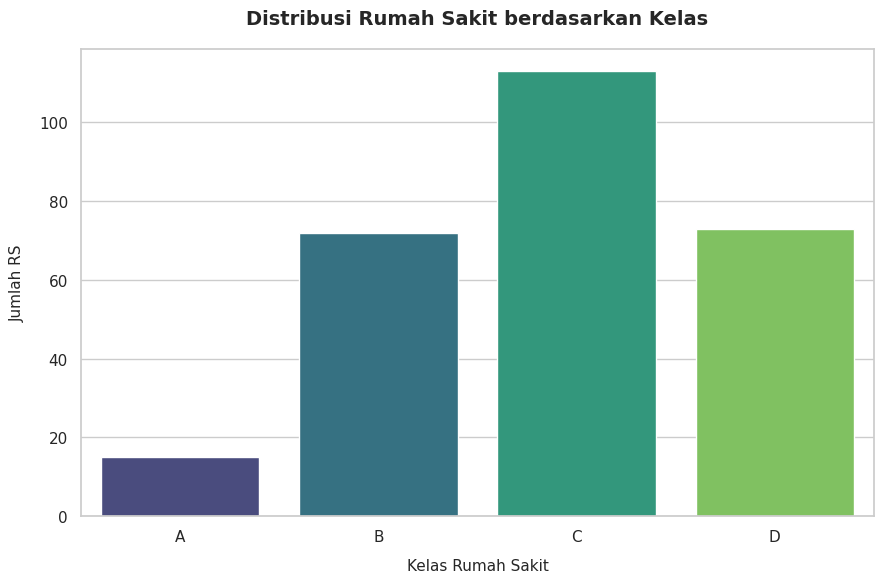

In [ ]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='kelas_rumah_sakit', order=['A', 'B', 'C', 'D'], palette='viridis')

plt.title('Distribusi Rumah Sakit berdasarkan Kelas', fontsize=14, pad=18, weight='bold')
plt.xlabel('Kelas Rumah Sakit', fontsize=11, labelpad=10)
plt.ylabel('Jumlah RS', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

### Jumlah Rumah Sakit berdasarkan Kepemilikan

In [ ]:
jumlah_rs_kepemilikan = df['kepemilikan'].value_counts().reset_index()
jumlah_rs_kepemilikan.columns = ['Kepemilikan', 'Jumlah RS']
print(jumlah_rs_kepemilikan.to_markdown())

|    | Kepemilikan       |   Jumlah RS |
|---:|:------------------|------------:|
|  0 | Swasta            |         110 |
|  1 | Pemerintah Daerah |         100 |
|  2 | Tni/Polri         |          28 |
|  3 | Pemerintah Pusat  |          24 |
|  4 | Bumn              |          11 |


/tmp/ipykernel_731/3316944904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='kepemilikan', order=df['kepemilikan'].value_counts().index, palette='plasma')


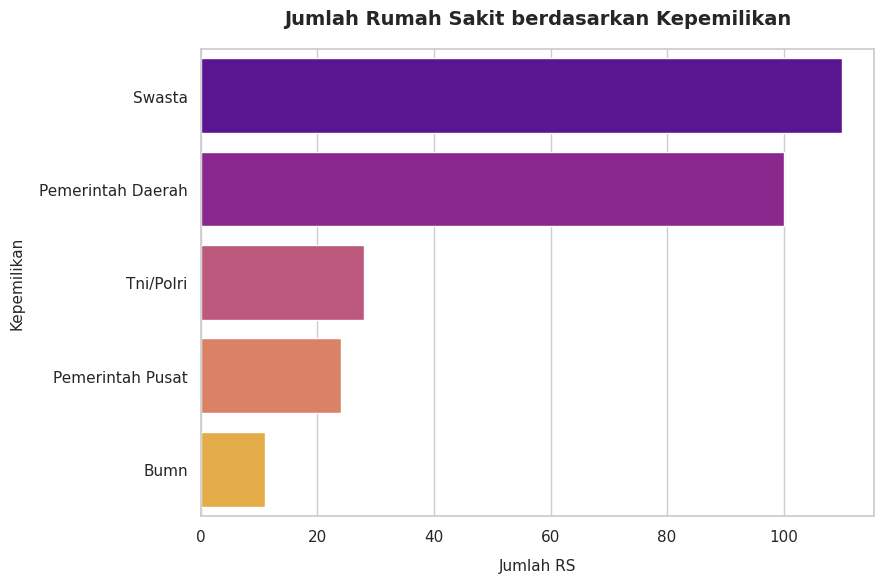

In [ ]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, y='kepemilikan', order=df['kepemilikan'].value_counts().index, palette='plasma')

plt.title('Jumlah Rumah Sakit berdasarkan Kepemilikan', fontsize=14, pad=18, weight='bold')
plt.xlabel('Jumlah RS', fontsize=11, labelpad=10)
plt.ylabel('Kepemilikan', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

### Distribusi Skor Persebaran Teknologi Digital

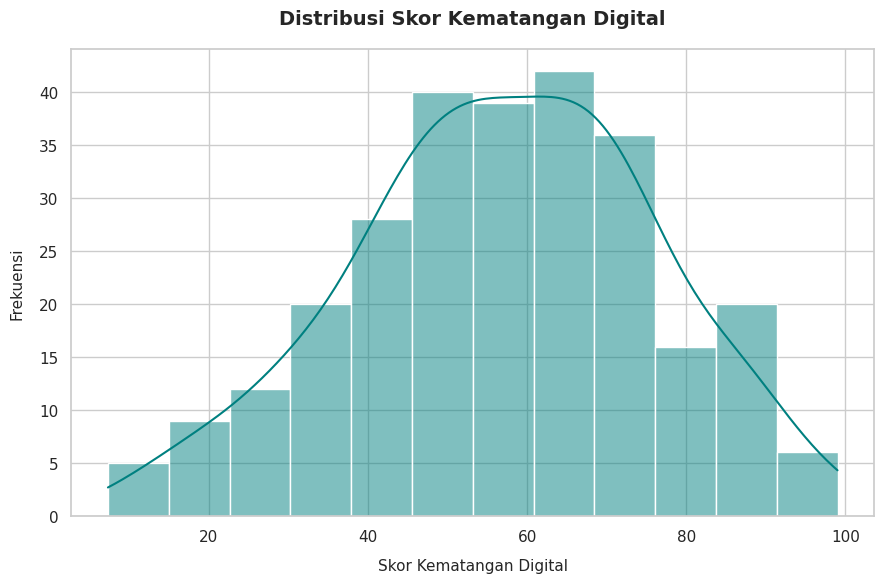

In [ ]:
plt.figure(figsize=(9, 6))
sns.histplot(data=df, x='skor_kematangan_digital', kde=True, color='teal')

plt.title('Distribusi Skor Kematangan Digital', fontsize=14, pad=18, weight='bold')
plt.xlabel('Skor Kematangan Digital', fontsize=11, labelpad=10)
plt.ylabel('Frekuensi', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

### Anggaran IT Tahunan Berdasarkan Kelas RS

In [ ]:
anggaran_it = df.groupby('kelas_rumah_sakit')['anggaran_it_tahunan_juta_rupiah'].agg(
    mean='mean',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).reset_index()
anggaran_it.columns = ['Kelas Rumah Sakit', 'Anggaran IT Tahunan (Rata-rata)', 'Batas Bawah Anggaran (Q1)', 'Batas Atas Anggaran (Q3)']
print(anggaran_it.to_markdown())

|    | Kelas Rumah Sakit   |   Anggaran IT Tahunan (Rata-rata) |   Batas Bawah Anggaran (Q1) |   Batas Atas Anggaran (Q3) |
|---:|:--------------------|----------------------------------:|----------------------------:|---------------------------:|
|  0 | A                   |                           128.737 |                     100.8   |                    152.45  |
|  1 | B                   |                           135.642 |                     102.925 |                    165.675 |
|  2 | C                   |                           117.823 |                      88.4   |                    144.4   |
|  3 | D                   |                           106.686 |                      78.4   |                    137.7   |


/tmp/ipykernel_731/1735534673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


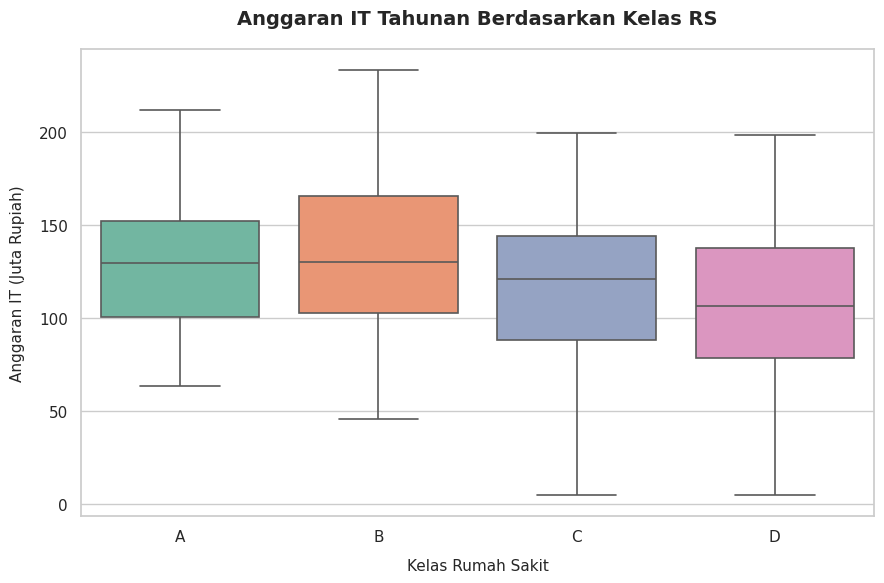

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='kelas_rumah_sakit',
    y='anggaran_it_tahunan_juta_rupiah',
    order=['A', 'B', 'C', 'D'],
    palette='Set2',
    linewidth=1.2,
    fliersize=5,
    flierprops={'markerfacecolor': '#e74c3c', 'markeredgecolor': 'w', 'alpha': 0.7})

plt.title('Anggaran IT Tahunan Berdasarkan Kelas RS', fontsize=14, pad=18, weight='bold')
plt.xlabel('Kelas Rumah Sakit', fontsize=11, labelpad=10)
plt.ylabel('Anggaran IT (Juta Rupiah)', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

### Korelasi Metrik Investasi IT vs Efisiensi Operasional

In [ ]:
rename_dict = {
    'anggaran_it_tahunan_juta_rupiah': 'Anggaran IT Tahunan',
    'jumlah_staf_it': 'Jumlah Staf IT',
    'jumlah_perangkat_iot': 'Jumlah Perangkat IoT',
    'skor_kematangan_digital': 'Skor Kematangan Digital',
    'kunjungan_telemedicine_per_bulan': 'Kunjungan Telemedicine',
    'tingkat_keterisian_tempat_tidur_persen': 'BOR (%)',
    'rata_rata_lama_rawat_hari': 'Lama Rawat (LOS)',
    'rata_rata_waktu_respons_rujukan_menit': 'Waktu Respons Rujukan',
    'kunjungan_pasien_per_bulan': 'Total Kunjungan Pasien'}

cols_for_corr = list(rename_dict.keys())
df_corr = df[cols_for_corr].rename(columns=rename_dict)
corr = df_corr.corr()

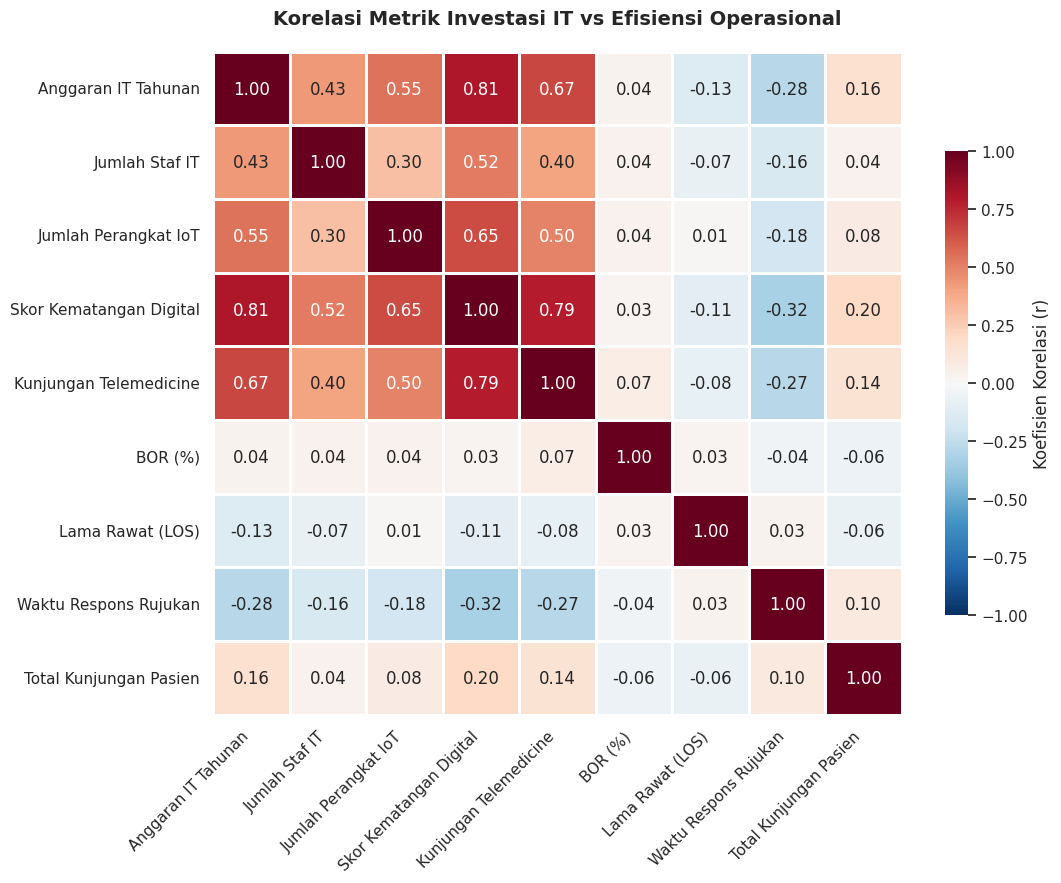

In [ ]:
plt.figure(figsize=(11, 9))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    fmt=".2f",
    linewidths=0.8,
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"shrink": 0.7, "label": "Koefisien Korelasi (r)"})

plt.title('Korelasi Metrik Investasi IT vs Efisiensi Operasional', fontsize=14, pad=20, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Anggaran IT Tahunan vs Skor Kematangan Digital

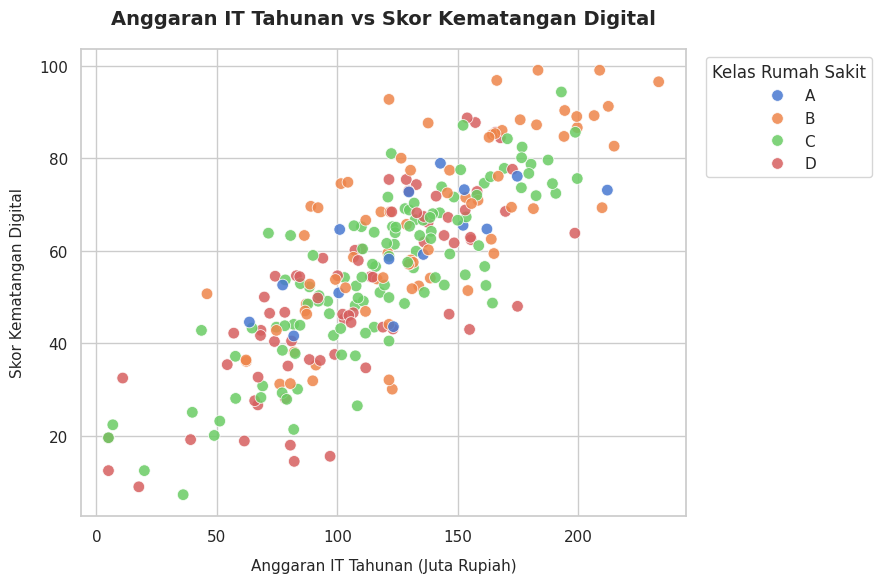

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='anggaran_it_tahunan_juta_rupiah',
    y='skor_kematangan_digital',
    hue='kelas_rumah_sakit',
    hue_order=['A', 'B', 'C', 'D'],
    palette='muted',
    alpha=0.85,
    s=70,
    edgecolor='w',
    linewidth=0.6)

plt.title('Anggaran IT Tahunan vs Skor Kematangan Digital', fontsize=14, pad=18, weight='bold')
plt.xlabel('Anggaran IT Tahunan (Juta Rupiah)', fontsize=11, labelpad=10)
plt.ylabel('Skor Kematangan Digital', fontsize=11, labelpad=10)
plt.legend(title='Kelas Rumah Sakit', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### Skor Kematangan Digital vs Waktu Respons Rujukan

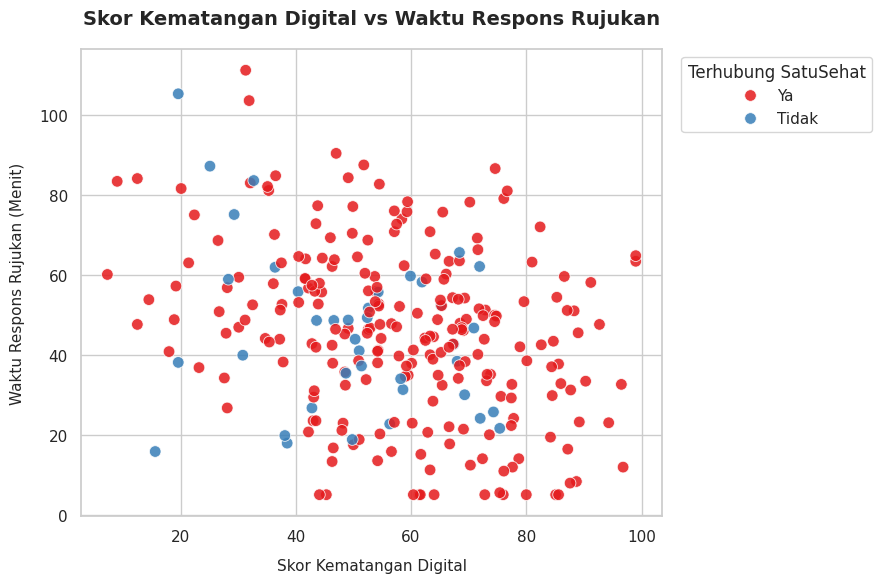

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='skor_kematangan_digital',
    y='rata_rata_waktu_respons_rujukan_menit',
    hue='status_terhubung_satusehat',
    hue_order=['Ya', 'Tidak'],
    palette='Set1',
    alpha=0.85,
    s=70,
    edgecolor='w',
    linewidth=0.6
)

plt.title('Skor Kematangan Digital vs Waktu Respons Rujukan', fontsize=14, pad=18, weight='bold')
plt.xlabel('Skor Kematangan Digital', fontsize=11, labelpad=10)
plt.ylabel('Waktu Respons Rujukan (Menit)', fontsize=11, labelpad=10)
plt.legend(title='Terhubung SatuSehat', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## **4. Analisis Kesenjangan Kematangan Digital**

Model yang digunakan: **Two-Way ANOVA**

Alasannya: Karena variabel dependennya berupa data numerik kontinu `(skor_kematangan_digital)`, sedangkan variabel independennya berupa data kategorik `(kelas_rumah_sakit dan kepemilikan)`.

In [ ]:
df = pd.read_csv('dataset_final.csv')

### Hipotesis

1. Efek Utama Kelas Rumah Sakit

Uji ini dilakukan untuk melihat pengaruh mandiri dari kapasitas fisik dan tingkatan rumah sakit (Kelas A, B, C, dan D) terhadap kesiapan teknologi mereka.
- **H₀ (Hipotesis Nol):** Tidak terdapat perbedaan rata-rata **skor kematangan digital** antar kelas rumah sakit (A, B, C, dan D).
- **H₁ (Hipotesis Alternatif):** Terdapat minimal satu kelas rumah sakit yang memiliki rata-rata **skor kematangan digital** yang berbeda.

---

2. Efek Utama Status Kepemilikan Rumah Sakit

Uji ini dilakukan untuk mengevaluasi apakah latar belakang manajemen institusi (Swasta, Pemerintah, TNI/Polri, BUMN) secara mandiri menciptakan kesenjangan dalam adopsi teknologi kesehatan.
- **H₀ (Hipotesis Nol):** Tidak terdapat perbedaan rata-rata **skor kematangan digital** berdasarkan status kepemilikan rumah sakit.
- **H₁ (Hipotesis Alternatif):** Terdapat minimal satu status kepemilikan rumah sakit yang memiliki rata-rata **skor kematangan digital** yang berbeda.

---

3. Efek Interaksi Kelas Rumah Sakit × Status Kepemilikan

Uji ini digunakan untuk mendeteksi adanya efek kombinasi yang unik, guna membuktikan apakah dampak kelas rumah sakit terhadap kesiapan digital polanya berbeda-beda atau bergantung pada siapa pemilik institusi tersebut.
- **H₀ (Hipotesis Nol):** Tidak terdapat interaksi antara **kelas rumah sakit** dan **status kepemilikan** terhadap **skor kematangan digital**.
- **H₁ (Hipotesis Alternatif):** Terdapat interaksi antara **kelas rumah sakit** dan **status kepemilikan** terhadap **skor kematangan digital**.

### Uji ANOVA (Run the Two-Way ANOVA)

In [ ]:
model_anova = ols('skor_kematangan_digital ~ C(kelas_rumah_sakit) * C(kepemilikan)', data=df).fit()
table_anova = sm.stats.anova_lm(model_anova, typ=2)

table_anova.columns = ['Sum of Squares (SS)', 'Degrees of Freedom (df)', 'F-Statistic', 'p-value (PR>F)']

ringkasan_garis("Hasil Pengujian Two-Way ANOVA")
print(table_anova.to_markdown())
print("\n*Catatan: Jika p-value (PR>F) < 0.05, maka faktor tersebut berpengaruh signifikan terhadap skor digital.")


 HASIL PENGUJIAN TWO-WAY ANOVA 
|                                     |   Sum of Squares (SS) |   Degrees of Freedom (df) |   F-Statistic |   p-value (PR>F) |
|:------------------------------------|----------------------:|--------------------------:|--------------:|-----------------:|
| C(kelas_rumah_sakit)                |               7910.56 |                         3 |       8.19053 |      3.17595e-05 |
| C(kepemilikan)                      |               4622.42 |                         4 |       3.58951 |      0.00722664  |
| C(kelas_rumah_sakit):C(kepemilikan) |               8214.13 |                        12 |       2.12621 |      0.0158727   |
| Residual                            |              81772.6  |                       254 |     nan       |    nan           |

*Catatan: Jika p-value (PR>F) < 0.05, maka faktor tersebut berpengaruh signifikan terhadap skor digital.


### Visualisasi

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
urutan_kelas = ['A', 'B', 'C', 'D']

/tmp/ipykernel_731/1459403921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


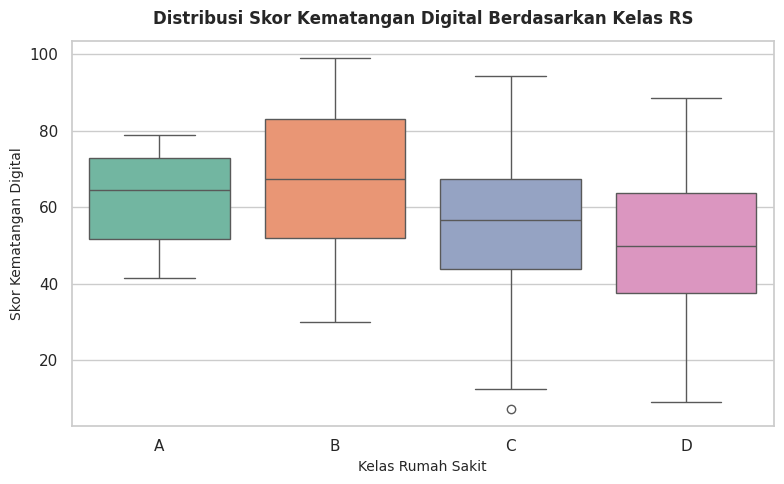

In [ ]:
# Boxplot skor digital berdasarkan kelas rumah sakit
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='kelas_rumah_sakit',
    y='skor_kematangan_digital',
    order=urutan_kelas,
    palette='Set2'
)
plt.title('Distribusi Skor Kematangan Digital Berdasarkan Kelas RS', fontsize=12, weight='bold', pad=12)
plt.xlabel('Kelas Rumah Sakit', fontsize=10)
plt.ylabel('Skor Kematangan Digital', fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_731/1155089458.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


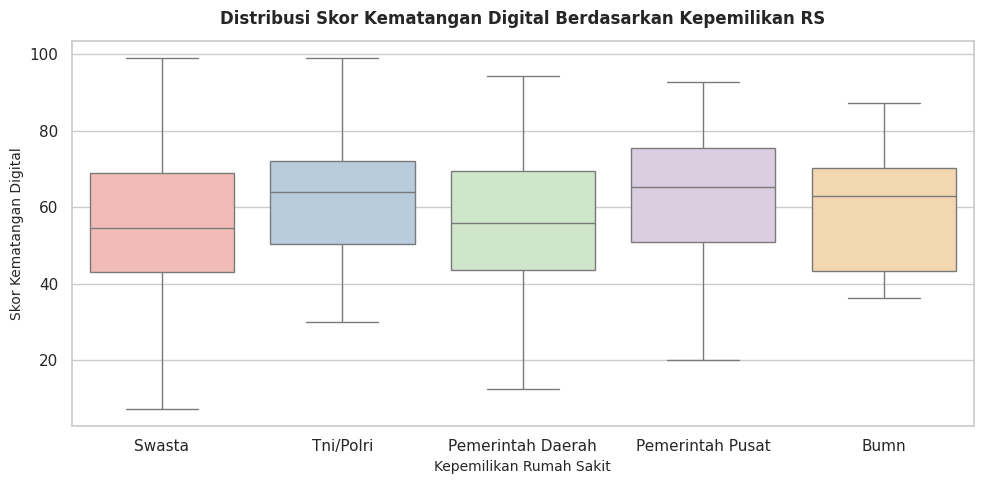

In [ ]:
# Boxplot skor digital berdasarkan kepemilikan RS
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='kepemilikan',
    y='skor_kematangan_digital',
    palette='Pastel1'
)
plt.title('Distribusi Skor Kematangan Digital Berdasarkan Kepemilikan RS', fontsize=12, weight='bold', pad=12)
plt.xlabel('Kepemilikan Rumah Sakit', fontsize=10)
plt.ylabel('Skor Kematangan Digital', fontsize=10)
plt.tight_layout()
plt.show()

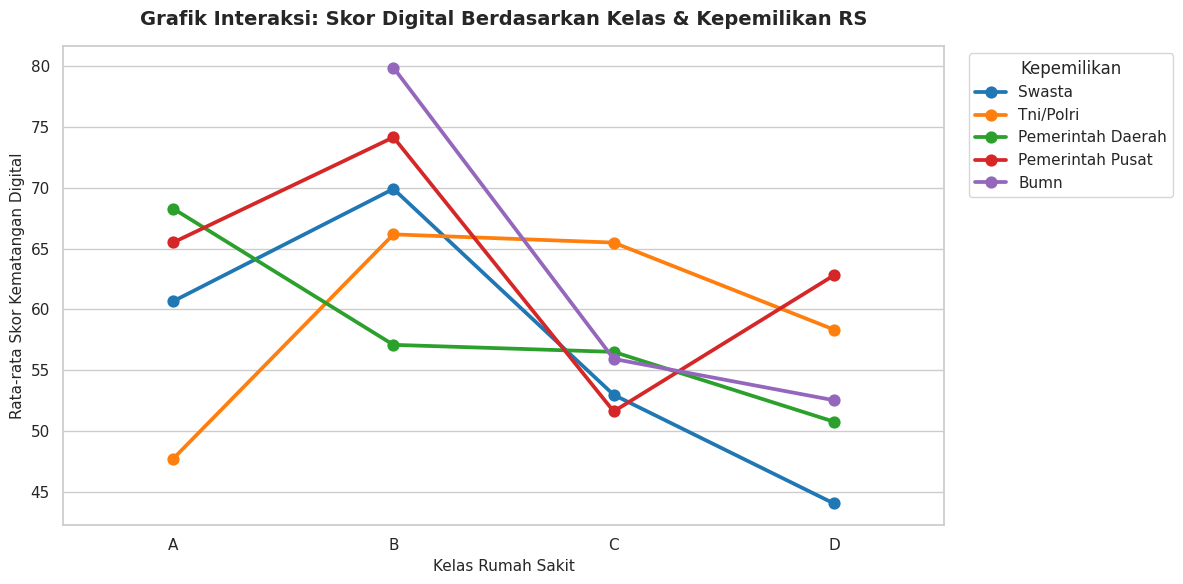

In [ ]:
# Grafik interaksi (p = 0.015)
plt.figure(figsize=(12, 6))
sns.pointplot(
    data=df,
    x='kelas_rumah_sakit',
    y='skor_kematangan_digital',
    hue='kepemilikan',
    order=urutan_kelas,
    estimator='mean',
    errorbar=None,
    palette='tab10')

plt.title('Grafik Interaksi: Skor Digital Berdasarkan Kelas & Kepemilikan RS', fontsize=14, weight='bold', pad=15)
plt.xlabel('Kelas Rumah Sakit', fontsize=11)
plt.ylabel('Rata-rata Skor Kematangan Digital', fontsize=11)
plt.legend(title='Kepemilikan', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Keputusan Hipotesis

In [ ]:
ringkasan_garis("Kesimpulan Uji Hipotesis (Alpha = 0.05)")

# 1. Keputusan untuk Faktor Kelas Rumah Sakit
p_kelas = table_anova.loc['C(kelas_rumah_sakit)', 'p-value (PR>F)']
print("1. Faktor Kelas Rumah Sakit:")
if p_kelas < 0.05:
    print(f"   - P-Value = {p_kelas:.6f} < 0.05 -> KEPUTUSAN: TOLAK H0")
    print("   - Kesimpulan: Variabel Kelas RS berpengaruh signifikan terhadap skor digital.")
else:
    print(f"   - P-Value = {p_kelas:.6f} >= 0.05 -> KEPUTUSAN: GAGAL TOLAK H0")
    print("   - Kesimpulan: Tidak ada perbedaan skor digital yang signifikan antar Kelas RS.")

print("-" * 80)

# 2. Keputusan untuk Faktor Kepemilikan
p_kepemilikan = table_anova.loc['C(kepemilikan)', 'p-value (PR>F)']
print("2. Faktor Status Kepemilikan RS:")
if p_kepemilikan < 0.05:
    print(f"   - P-Value = {p_kepemilikan:.6f} < 0.05 -> KEPUTUSAN: TOLAK H0")
    print("   - Kesimpulan: Variabel Status Kepemilikan berpengaruh signifikan terhadap skor digital.")
else:
    print(f"   - P-Value = {p_kepemilikan:.6f} >= 0.05 -> KEPUTUSAN: GAGAL TOLAK H0")
    print("   - Kesimpulan: Tidak ada perbedaan skor digital yang signifikan antar Status Kepemilikan.")

print("-" * 80)

# 3. Keputusan untuk Efek Interaksi
p_interaksi = table_anova.loc['C(kelas_rumah_sakit):C(kepemilikan)', 'p-value (PR>F)']
print("3. Efek Interaksi (Kelas x Kepemilikan):")
if p_interaksi < 0.05:
    print(f"   - P-Value = {p_interaksi:.6f} < 0.05 -> KEPUTUSAN: TOLAK H0")
    print("   - Kesimpulan: Terdapat efek interaksi yang signifikan. Pengaruh Kelas RS terhadap skor digital bergantung pada jenis Kepemilikannya.")
else:
    print(f"   - P-Value = {p_interaksi:.6f} >= 0.05 -> KEPUTUSAN: GAGAL TOLAK H0")
    print("   - Kesimpulan: Tidak ada efek interaksi yang signifikan.")


 KESIMPULAN UJI HIPOTESIS (ALPHA = 0.05) 
1. Faktor Kelas Rumah Sakit:
   - P-Value = 0.000032 < 0.05 -> KEPUTUSAN: TOLAK H0
   - Kesimpulan: Variabel Kelas RS berpengaruh signifikan terhadap skor digital.
--------------------------------------------------------------------------------
2. Faktor Status Kepemilikan RS:
   - P-Value = 0.007227 < 0.05 -> KEPUTUSAN: TOLAK H0
   - Kesimpulan: Variabel Status Kepemilikan berpengaruh signifikan terhadap skor digital.
--------------------------------------------------------------------------------
3. Efek Interaksi (Kelas x Kepemilikan):
   - P-Value = 0.015873 < 0.05 -> KEPUTUSAN: TOLAK H0
   - Kesimpulan: Terdapat efek interaksi yang signifikan. Pengaruh Kelas RS terhadap skor digital bergantung pada jenis Kepemilikannya.


### Effect Size

Alasan dilakukannya effect size adalah untuk melihat seberapa besar variabel itu memengaruhi skor digital.

In [ ]:
table_anova['Partial Eta Squared (ηp²)'] = table_anova['Sum of Squares (SS)'] / (table_anova['Sum of Squares (SS)'] + table_anova.loc['Residual', 'Sum of Squares (SS)'])

ringkasan_garis("Kekuatan Efek / Effect Size (Partial Eta Squared)")
print(table_anova[['Partial Eta Squared (ηp²)']].to_markdown())
print("\n*Catatan: Nilai ηp² menunjukkan persentase varians skor digital yang mampu dijelaskan oleh masing-masing faktor.")


 KEKUATAN EFEK / EFFECT SIZE (PARTIAL ETA SQUARED) 
|                                     |   Partial Eta Squared (ηp²) |
|:------------------------------------|----------------------------:|
| C(kelas_rumah_sakit)                |                   0.0882056 |
| C(kepemilikan)                      |                   0.0535033 |
| C(kelas_rumah_sakit):C(kepemilikan) |                   0.0912815 |
| Residual                            |                   0.5       |

*Catatan: Nilai ηp² menunjukkan persentase varians skor digital yang mampu dijelaskan oleh masing-masing faktor.


### Visualisasi

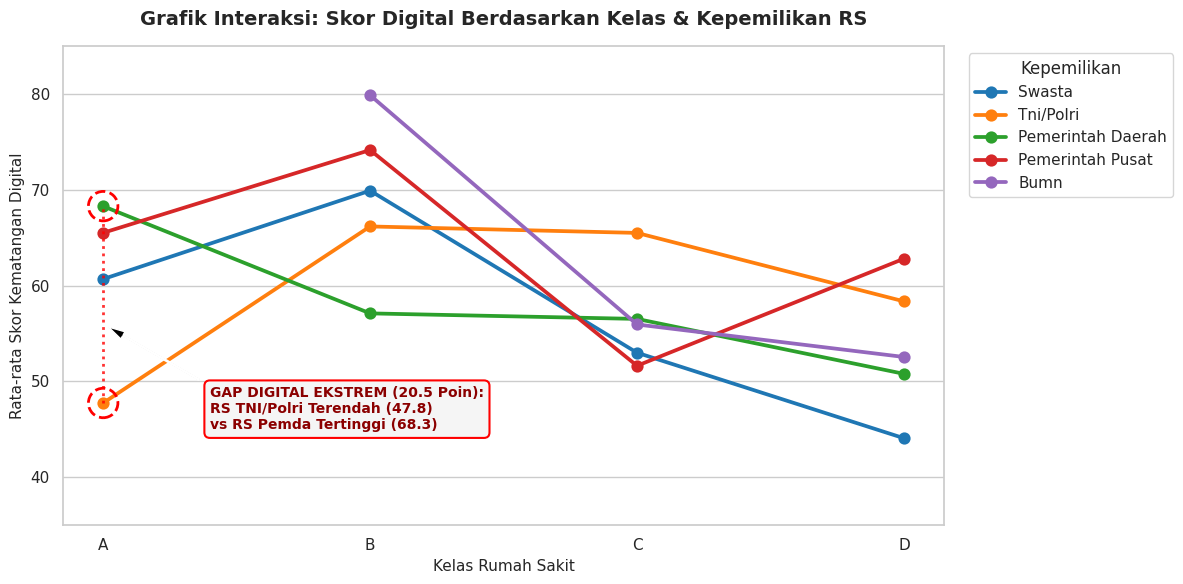

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.pointplot(
    data=df, x='kelas_rumah_sakit', y='skor_kematangan_digital', hue='kepemilikan',
    order=urutan_kelas, estimator='mean', errorbar=None, palette='tab10')

plt.scatter([0], [47.75], s=450, facecolors='none', edgecolors='red', linewidths=2, linestyle='--', zorder=5)
plt.scatter([0], [68.28], s=450, facecolors='none', edgecolors='red', linewidths=2, linestyle='--', zorder=5)
plt.plot([0, 0], [47.75, 68.28], color='red', linestyle=':', linewidth=2, alpha=0.8)

ax.annotate(
    'GAP DIGITAL EKSTREM (20.5 Poin):\nRS TNI/Polri Terendah (47.8)\nvs RS Pemda Tertinggi (68.3)',
    xy=(0, 56),
    xytext=(0.4, 45),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=10,
    weight='bold',
    color='darkred',
    bbox=dict(boxstyle="round,pad=0.4", fc="whitesmoke", ec="red", lw=1.5))

plt.title('Grafik Interaksi: Skor Digital Berdasarkan Kelas & Kepemilikan RS', fontsize=14, weight='bold', pad=15)
plt.xlabel('Kelas Rumah Sakit', fontsize=11)
plt.ylabel('Rata-rata Skor Kematangan Digital', fontsize=11)
plt.legend(title='Kepemilikan', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(35, 85)
plt.tight_layout()
plt.show()

### Uji Tukey's HSD

Untuk validasi hasil visualisasi grafik interaksi.

In [ ]:
df['kelompok_interaksi'] = df['kelas_rumah_sakit'] + "_" + df['kepemilikan']
uji_tukey = pairwise_tukeyhsd(endog=df['skor_kematangan_digital'], groups=df['kelompok_interaksi'], alpha=0.05)
df_tukey = pd.DataFrame(uji_tukey.summary().data[1:], columns=uji_tukey.summary().data[0])
df_signifikan = df_tukey[df_tukey['reject'] == True].copy()
df_kesenjangan_kritis = df_signifikan.sort_values(by='meandiff', key=abs, ascending=False)

df_kesenjangan_kritis.columns = [
    'Kelompok RS (A)',
    'Kelompok RS (B)',
    'Jurang Skor (Meandiff)',
    'p-adj (Signifikansi)',
    'Batasan Bawah',
    'Batasan Atas',
    'Signifikan?']

ringkasan_garis("Temuan Utama: Tabel Jurang Kesenjangan Digital Tertinggi")
print(df_kesenjangan_kritis[['Kelompok RS (A)', 'Kelompok RS (B)', 'Jurang Skor (Meandiff)', 'p-adj (Signifikansi)']].to_markdown(index=False))


 TEMUAN UTAMA: TABEL JURANG KESENJANGAN DIGITAL TERTINGGI 
| Kelompok RS (A)    | Kelompok RS (B)     |   Jurang Skor (Meandiff) |   p-adj (Signifikansi) |
|:-------------------|:--------------------|-------------------------:|-----------------------:|
| B_Pemerintah Pusat | D_Swasta            |                 -30.0564 |                 0.0315 |
| B_Swasta           | D_Swasta            |                 -25.8194 |                 0.0001 |
| B_Swasta           | D_Pemerintah Daerah |                 -19.1066 |                 0.0118 |
| B_Swasta           | C_Swasta            |                 -16.9024 |                 0.0142 |


## **5. Evaluasi Dampak Operasional**

Model yang digunakan: **Multiple Linear Regression**

Alasannya: Karena metode ini memungkinkan analisis pengaruh variabel independen secara simultan (simultaneous testing), sehingga meminimalisir omitted variable bias dan memastikan bahwa estimasi dampak dari setiap faktor (Skor Digital, RME, dan SatuSehat) terukur secara akurat tanpa terdistorsi oleh variabel lain.

### Hipotesis

1. Hipotesis untuk Dampak Implementasi RME

Uji ini dilakukan untuk melihat apakah rekam medis elektronik mempercepat waktu pelayanan rujukan.
*   $H_0$ (Hipotesis Nol): Tidak ada perbedaan rata-rata waktu respons rujukan antara rumah sakit yang sudah mengimplementasikan RME dan rumah sakit yang belum mengimplementasikan RME ($\mu_{\text{RME}} = \mu_{\text{Non-RME}}$).
*   $H_1$ (Hipotesis Alternatif): Rumah sakit yang sudah mengimplementasikan RME memiliki rata-rata waktu respons rujukan yang lebih kecil (lebih cepat) secara signifikan dibandingkan rumah sakit yang belum mengimplementasikan RME ($\mu_{\text{RME}} < \mu_{\text{Non-RME}}$).

---

2. Hipotesis untuk Dampak Koneksi SatuSehat

Uji ini dilakukan untuk melihat apakah integrasi dengan platform ekosistem SatuSehat memotong birokrasi dan waktu rujukan.
*   $H_0$ (Hipotesis Nol): Tidak ada perbedaan rata-rata waktu respons rujukan antara rumah sakit yang sudah terhubung dengan ekosistem SatuSehat dan rumah sakit yang belum terhubung ($\mu_{\text{SatuSehat}} = \mu_{\text{Non-SatuSehat}}$).
*   $H_1$ (Hipotesis Alternatif): Rumah sakit yang sudah terhubung dengan ekosistem SatuSehat memiliki rata-rata waktu respons rujukan yang lebih kecil (lebih cepat) secara signifikan dibandingkan rumah sakit yang belum terhubung ($\mu_{\text{SatuSehat}} < \mu_{\text{Non-SatuSehat}}$).

---

3. Hipotesis untuk Dampak Skor Kematangan Digital (Analisis Korelasi)

Uji ini digunakan untuk melihat hubungan linear kontinu antara tingkat digitalisasi dengan metrik operasional (waktu respons dan kunjungan telemedicine).

Terhadap Waktu Respons Rujukan:
*   $H_0$: Tidak ada hubungan linear (korelasi) antara skor kematangan digital rumah sakit dengan waktu respons rujukan ($\rho = 0$).
*   $H_1$: Terdapat hubungan linear negatif yang signifikan antara skor kematangan digital dengan waktu respons rujukan ($\rho < 0$), artinya semakin tinggi tingkat kematangan digital, maka waktu respons rujukan akan semakin menurun (semakin cepat).

Terhadap Kunjungan Telemedicine:
*   $H_0$: Tidak ada hubungan linear (korelasi) antara skor kematangan digital rumah sakit dengan jumlah kunjungan telemedicine per bulan ($\rho = 0$).
*   $H_1$: Terdapat hubungan linear positif yang signifikan antara skor kematangan digital dengan jumlah kunjungan telemedicine per bulan ($\rho > 0$), artinya semakin matang digitalisasi suatu rumah sakit, maka volume pemanfaatan layanan telemedicine akan semakin meningkat.

### Analisis Deskriptif Grup

In [ ]:
df_reg = df.copy()
for col in ['status_implementasi_rme', 'status_terhubung_satusehat']:
    df_reg[col] = df_reg[col].astype(str).str.strip().map({'Sudah': 1, 'Belum': 0, 'Ya': 1, 'Tidak': 0})

In [ ]:
print("Rata-Rata Waktu Respons berdasarkan Grup")
print("\n[1] Berdasarkan Implementasi RME:")
print(df.groupby('status_implementasi_rme')['rata_rata_waktu_respons_rujukan_menit'].mean())
print("\n[2] Berdasarkan Koneksi SatuSehat:")
print(df.groupby('status_terhubung_satusehat')['rata_rata_waktu_respons_rujukan_menit'].mean())

Rata-Rata Waktu Respons berdasarkan Grup

[1] Berdasarkan Implementasi RME:
status_implementasi_rme
Tidak    47.672727
Ya       45.531076
Name: rata_rata_waktu_respons_rujukan_menit, dtype: float64

[2] Berdasarkan Koneksi SatuSehat:
status_terhubung_satusehat
Tidak    45.641026
Ya       45.714103
Name: rata_rata_waktu_respons_rujukan_menit, dtype: float64


### Uji Hipotesis Parsial (Welch's T-Test)

In [ ]:
print("Uji-T Parsial")
t_test_rme = pg.ttest(
    x=df[df['status_implementasi_rme'] == 'Ya']['rata_rata_waktu_respons_rujukan_menit'],
    y=df[df['status_implementasi_rme'] == 'Tidak']['rata_rata_waktu_respons_rujukan_menit'],
    correction=True
)
print("\n[1] Hasil Uji-T untuk Dampak Implementasi RME:")
display(t_test_rme)

t_test_satusehat = pg.ttest(
    x=df[df['status_terhubung_satusehat'] == 'Ya']['rata_rata_waktu_respons_rujukan_menit'],
    y=df[df['status_terhubung_satusehat'] == 'Tidak']['rata_rata_waktu_respons_rujukan_menit'],
    correction=True
)
print("\n[2] Hasil Uji-T untuk Dampak Koneksi SatuSehat:")
display(t_test_satusehat)

Uji-T Parsial

[1] Hasil Uji-T untuk Dampak Implementasi RME:


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-0.438304,24.520049,two-sided,0.665004,"[-12.22, 7.93]",0.100819,0.073697,0.251



[2] Hasil Uji-T untuk Dampak Koneksi SatuSehat:


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,0.020628,53.039324,two-sided,0.98362,"[-7.03, 7.18]",0.003439,0.050045,0.185


### Visualisasi Distribusi Bar Plot

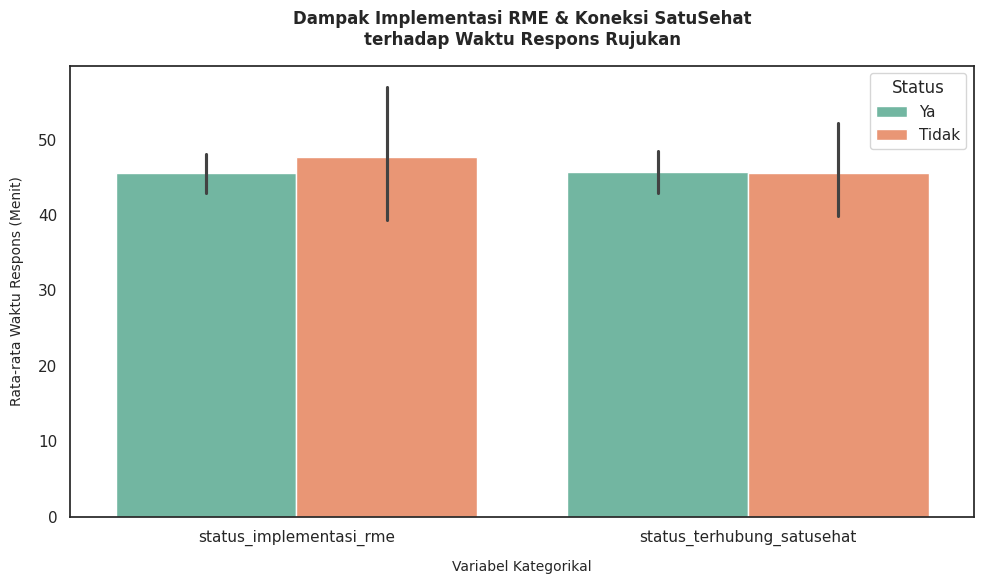

In [ ]:
df_melted = df.melt(
    value_vars=['status_implementasi_rme', 'status_terhubung_satusehat'],
    var_name='Jenis_Kategori',
    value_name='Status')

df_melted['Waktu_Respons'] = df['rata_rata_waktu_respons_rujukan_menit'].tolist() * 2

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melted,
    x='Jenis_Kategori',
    y='Waktu_Respons',
    hue='Status',
    palette='Set2')

plt.title('Dampak Implementasi RME & Koneksi SatuSehat\nterhadap Waktu Respons Rujukan', fontsize=12, weight='bold', pad=15)
plt.xlabel('Variabel Kategorikal', fontsize=10, labelpad=10)
plt.ylabel('Rata-rata Waktu Respons (Menit)', fontsize=10, labelpad=10)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

### Analisis Tren Korelasi Kontinu

In [ ]:
print("Matriks Korelasi Pearson")
korelasi_ops = df[['skor_kematangan_digital', 'rata_rata_waktu_respons_rujukan_menit', 'kunjungan_telemedicine_per_bulan']].corr()
print(korelasi_ops.to_markdown())

Matriks Korelasi Pearson
|                                       |   skor_kematangan_digital |   rata_rata_waktu_respons_rujukan_menit |   kunjungan_telemedicine_per_bulan |
|:--------------------------------------|--------------------------:|----------------------------------------:|-----------------------------------:|
| skor_kematangan_digital               |                  1        |                               -0.322936 |                           0.78795  |
| rata_rata_waktu_respons_rujukan_menit |                 -0.322936 |                                1        |                          -0.273618 |
| kunjungan_telemedicine_per_bulan      |                  0.78795  |                               -0.273618 |                           1        |


### Visualisasi Tren Garis Regresi Eksploratif

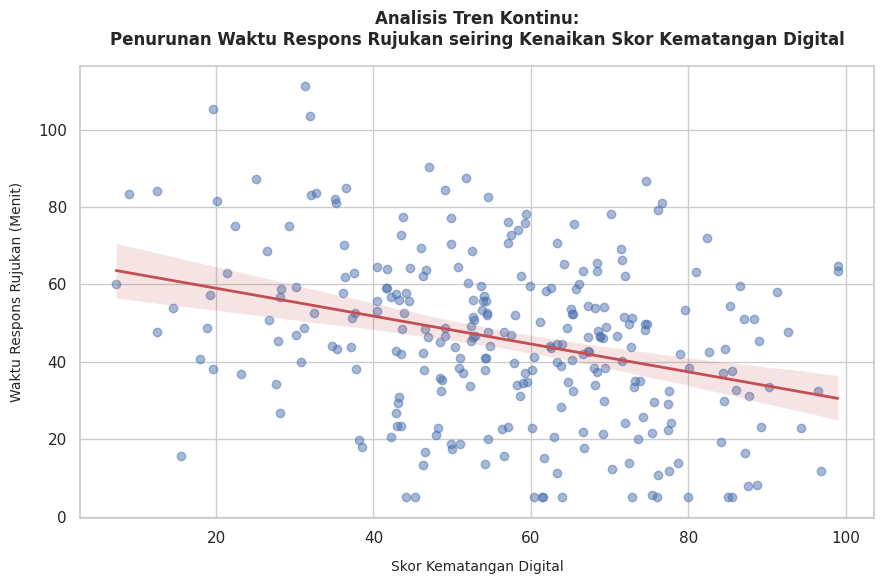

In [ ]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x='skor_kematangan_digital', y='rata_rata_waktu_respons_rujukan_menit',
            scatter_kws={'alpha':0.5, 'color': '#4c72b0'}, line_kws={'color':'#c44e52', 'linewidth': 2})
plt.title('Analisis Tren Kontinu:\nPenurunan Waktu Respons Rujukan seiring Kenaikan Skor Kematangan Digital', fontsize=12, weight='bold', pad=15)
plt.xlabel('Skor Kematangan Digital', fontsize=10, labelpad=10)
plt.ylabel('Waktu Respons Rujukan (Menit)', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

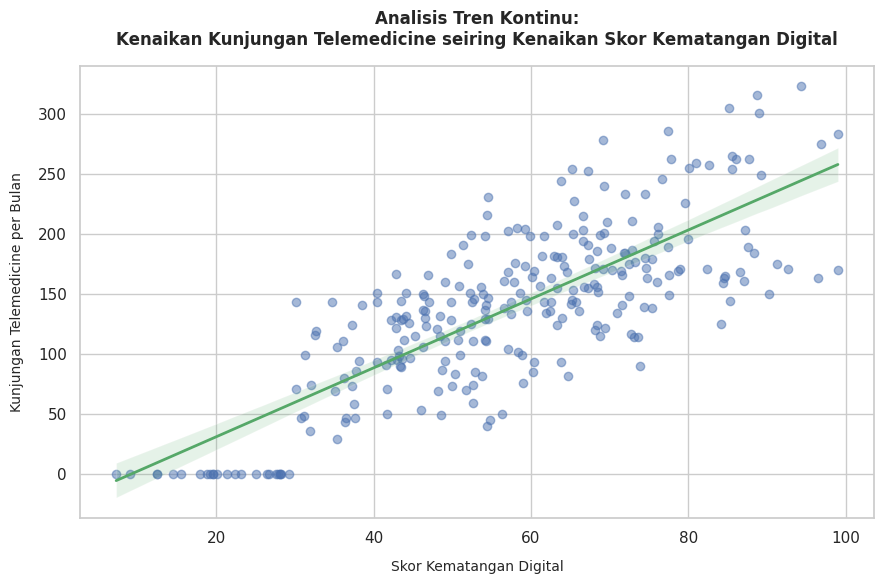

In [ ]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x='skor_kematangan_digital', y='kunjungan_telemedicine_per_bulan',
            scatter_kws={'alpha':0.5, 'color': '#4c72b0'}, line_kws={'color':'#55a868', 'linewidth': 2})
plt.title('Analisis Tren Kontinu:\nKenaikan Kunjungan Telemedicine seiring Kenaikan Skor Kematangan Digital', fontsize=12, weight='bold', pad=15)
plt.xlabel('Skor Kematangan Digital', fontsize=10, labelpad=10)
plt.ylabel('Kunjungan Telemedicine per Bulan', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

### Uji Multikolinearitas (VIF)

In [ ]:
print("Uji Multikolinearitas (VIF)")
X_vif = df_reg[['skor_kematangan_digital', 'status_implementasi_rme', 'status_terhubung_satusehat']].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variabel"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data.to_markdown(index=False))

Uji Multikolinearitas (VIF)
| Variabel                   |      VIF |
|:---------------------------|---------:|
| const                      | 19.1099  |
| skor_kematangan_digital    |  1.02486 |
| status_implementasi_rme    |  2.11119 |
| status_terhubung_satusehat |  2.12431 |


### Fitting Model

In [ ]:
print("Fitting Model dan Ringkasan Output Regresi")
rumus_regresi = "rata_rata_waktu_respons_rujukan_menit ~ skor_kematangan_digital + status_implementasi_rme + status_terhubung_satusehat"
model_regresi = ols(rumus_regresi, data=df_reg).fit()

teks_summary = str(model_regresi.summary())
teks_summary = teks_summary.replace("Notes:", "Catatan:")
teks_summary = teks_summary.replace(
    "[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.",
    "[1] Kesalahan Standar (Standard Errors) mengasumsikan bahwa matriks kovarians dari kesalahan (error) telah dispesifikasikan dengan benar.")

print(teks_summary)

Fitting Model dan Ringkasan Output Regresi
                                      OLS Regression Results                                     
Dep. Variable:     rata_rata_waktu_respons_rujukan_menit   R-squared:                       0.108
Model:                                               OLS   Adj. R-squared:                  0.098
Method:                                    Least Squares   F-statistic:                     10.84
Date:                                   Sat, 18 Jul 2026   Prob (F-statistic):           9.52e-07
Time:                                           10:37:45   Log-Likelihood:                -1205.2
No. Observations:                                    273   AIC:                             2418.
Df Residuals:                                        269   BIC:                             2433.
Df Model:                                              3                                         
Covariance Type:                               nonrobust                   

### Uji Formal Asumsi Residual

In [ ]:
residual = model_regresi.resid
fitted_values = model_regresi.fittedvalues

In [ ]:
# Uji Normalitas Formal
_, p_shapiro = stats.shapiro(residual)
print(f"Uji Normalitas Shapiro-Wilk (p-value): {p_shapiro:.4f}")
print("Kesimpulan: " + ("Residual terdistribusi normal (Asumsi Terpenuhi)." if p_shapiro > 0.05 else "Residual tidak terdistribusi normal."))

Uji Normalitas Shapiro-Wilk (p-value): 0.2438
Kesimpulan: Residual terdistribusi normal (Asumsi Terpenuhi).


In [ ]:
# Uji Homoskedastisitas Formal
uji_bp = sms.het_breuschpagan(residual, model_regresi.model.exog)
print(f"Uji Homoskedastisitas Breusch-Pagan (p-value): {uji_bp[1]:.4f}")
print("Kesimpulan: " + ("Varians residual konstan / Homoskedastisitas (Asumsi Terpenuhi)." if uji_bp[1] > 0.05 else "Terjadi gejala Heteroskedastisitas."))

Uji Homoskedastisitas Breusch-Pagan (p-value): 0.8639
Kesimpulan: Varians residual konstan / Homoskedastisitas (Asumsi Terpenuhi).


### Visualisasi

In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
sns.set_theme(style="whitegrid", rc={"font.family": "sans-serif"})

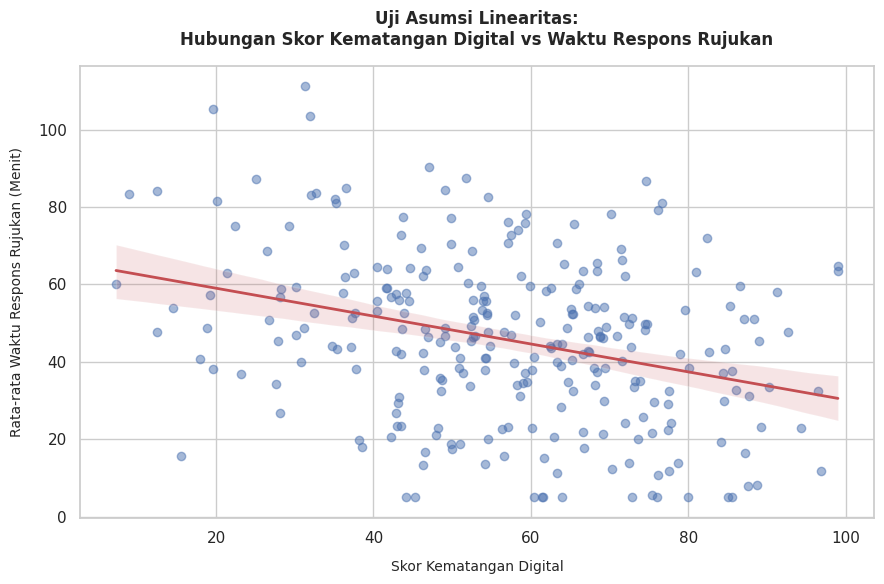

In [ ]:
# Grafik Linearitas
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_reg,
    x='skor_kematangan_digital',
    y='rata_rata_waktu_respons_rujukan_menit',
    scatter_kws={'alpha': 0.5, 'color': '#4c72b0'},
    line_kws={'color': '#c44e52', 'linewidth': 2})

plt.title('Uji Asumsi Linearitas:\nHubungan Skor Kematangan Digital vs Waktu Respons Rujukan', fontsize=12, weight='bold', pad=15)
plt.xlabel('Skor Kematangan Digital', fontsize=10, labelpad=10)
plt.ylabel('Rata-rata Waktu Respons Rujukan (Menit)', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

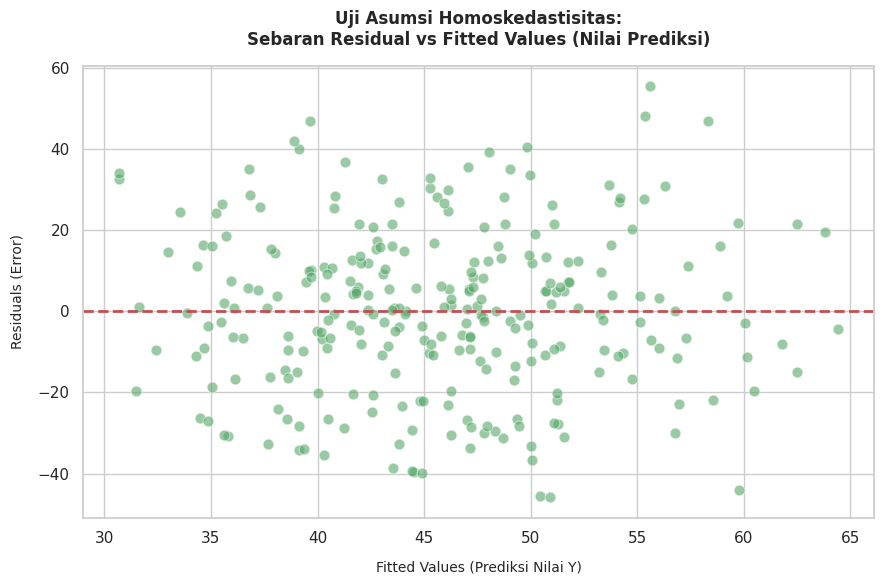

In [ ]:
# Grafik Homoskedastisitas
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=fitted_values,
    y=residual,
    alpha=0.6,
    color='#55a868',
    s=60)

plt.axhline(y=0, color='#c44e52', linestyle='--', linewidth=2)
plt.title('Uji Asumsi Homoskedastisitas:\nSebaran Residual vs Fitted Values (Nilai Prediksi)', fontsize=12, weight='bold', pad=15)
plt.xlabel('Fitted Values (Prediksi Nilai Y)', fontsize=10, labelpad=10)
plt.ylabel('Residuals (Error)', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

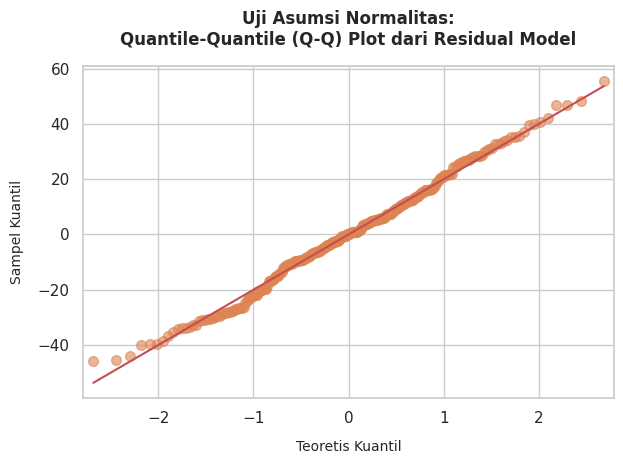

In [ ]:
# Grafik Normalitas
plt.figure(figsize=(9, 6))

fig = sm.qqplot(residual, line='s')
ax = fig.gca()

titik_sampel = ax.get_lines()[0]
titik_sampel.set_markerfacecolor('#dd8452')
titik_sampel.set_markeredgecolor('#dd8452')
titik_sampel.set_alpha(0.6)
titik_sampel.set_markersize(7)

plt.title('Uji Asumsi Normalitas:\nQuantile-Quantile (Q-Q) Plot dari Residual Model', fontsize=12, weight='bold', pad=15)
plt.xlabel('Teoretis Kuantil', fontsize=10, labelpad=10)
plt.ylabel('Sampel Kuantil', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

### Keputusan Hipotesis

Berdasarkan hasil pengujian statistik dengan tingkat signifikansi **α = 0,05**, diperoleh interpretasi sebagai berikut.

1. Dampak Implementasi Rekam Medis Elektronik (RME) *(Uji-t Parsial)*

- **Keputusan:** Gagal menolak **H₀**.
- **p-value:** **0,6650** (> 0,05).

**Interpretasi:**
Tidak terdapat perbedaan yang signifikan pada rata-rata waktu respons rujukan antara rumah sakit yang telah mengimplementasikan **Rekam Medis Elektronik (RME)** dan rumah sakit yang belum mengimplementasikan RME.

---

2. Dampak Integrasi SatuSehat *(Uji-t Parsial)*

- **Keputusan:** Gagal menolak **H₀**.
- **p-value:** **0,9836** (> 0,05).

**Interpretasi:**
Tidak terdapat perbedaan yang signifikan pada rata-rata waktu respons rujukan antara rumah sakit yang telah terhubung dengan **SatuSehat** dan rumah sakit yang belum terhubung.

---

3. Hubungan Skor Kematangan Digital *(Analisis Korelasi)*

Terhadap Waktu Respons Rujukan

- **Keputusan:** Menolak **H₀**.
- **p-value:** **< 0,001**.

**Interpretasi:**
Terdapat hubungan linear negatif yang signifikan antara **skor kematangan digital** dan **waktu respons rujukan**. Semakin tinggi skor kematangan digital rumah sakit, semakin singkat waktu respons rujukan.

---

Terhadap Kunjungan Telemedicine

- **Keputusan:** Menolak **H₀**.
- **p-value:** **< 0,001**.

**Interpretasi:**
Terdapat hubungan linear positif yang signifikan antara **skor kematangan digital** dan **jumlah kunjungan telemedicine**. Semakin tinggi tingkat kematangan digital rumah sakit, semakin tinggi pula pemanfaatan layanan telemedicine.

---

Analisis Regresi Linear Berganda (OLS)

- **Keputusan:** Menolak **H₀**.
- **Prob (F-statistic):** **9,52 × 10⁻⁷** (< 0,05).

**Interpretasi:**
Secara simultan, variabel **implementasi RME**, **status koneksi SatuSehat**, dan **skor kematangan digital** berpengaruh signifikan terhadap **waktu respons rujukan**. Hal ini menunjukkan bahwa ketiga variabel tersebut secara bersama-sama mampu menjelaskan variasi waktu respons rujukan pada rumah sakit.

## **6. Identifikasi Akar Masalah (Bottleneck)**

Model yang digunakan: **Prioritization Matrix** (1)

Alasannya: Metode ini dapat membantu dalam membuat rekomendasi strategis yang intuitif dan mudah dipahami oleh pembuat kebijakan kesehatan (actionable insights).

### Standardisasi Data

Mengubah variabel BOR (persentase) dan variabel Kunjungan Pasien (angka ribuan) ke dalam rentang nilai 0-1 menggunakan teknik Min-Max normalisasi agar tidak bias akibat perbedaan satuan data.

In [ ]:
df_pilar_c = df.copy()

In [ ]:
bor_min, bor_max = df_pilar_c['tingkat_keterisian_tempat_tidur_persen'].min(), df_pilar_c['tingkat_keterisian_tempat_tidur_persen'].max()
kunj_min, kunj_max = df_pilar_c['kunjungan_pasien_per_bulan'].min(), df_pilar_c['kunjungan_pasien_per_bulan'].max()

df_pilar_c['bor_scaled'] = (df_pilar_c['tingkat_keterisian_tempat_tidur_persen'] - bor_min) / (bor_max - bor_min)
df_pilar_c['kunjungan_scaled'] = (df_pilar_c['kunjungan_pasien_per_bulan'] - kunj_min) / (kunj_max - kunj_min)

### Skor Komposit Beban Operasional

Menghitung rata-rata nilai terstandardisasi dari langkah pertama guna melahirkan variabel komposit baru bernama beban_operasional.

In [ ]:
df_pilar_c['beban_operasional'] = (df_pilar_c['bor_scaled'] + df_pilar_c['kunjungan_scaled']) / 2

### Threshold

Mencari nilai rata-rata (mean) populasi pada variabel kematangan digital dan beban operasional untuk dijadikan batas koordinat persilangan kuadran.

In [ ]:
x_mean_threshold = df_pilar_c['skor_kematangan_digital'].mean()
y_mean_threshold = df_pilar_c['beban_operasional'].mean()

### Pelabelan Kuadran

In [ ]:
def klasifikasi_kuadran_makro(row):
    if row['skor_kematangan_digital'] >= x_mean_threshold and row['beban_operasional'] < y_mean_threshold:
        return 'RS Unggulan'
    elif row['skor_kematangan_digital'] >= x_mean_threshold and row['beban_operasional'] >= y_mean_threshold:
        return 'Perlu Peningkatan Kapasitas'
    elif row['skor_kematangan_digital'] < x_mean_threshold and row['beban_operasional'] < y_mean_threshold:
        return 'Potensial Ditingkatkan'
    else:
        return 'Prioritas Utama Transformasi'

df_pilar_c['kuadran_prioritas'] = df_pilar_c.apply(klasifikasi_kuadran_makro, axis=1)

### Visualisasi

In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
sns.set_theme(style="whitegrid", rc={"font.family": "sans-serif"})

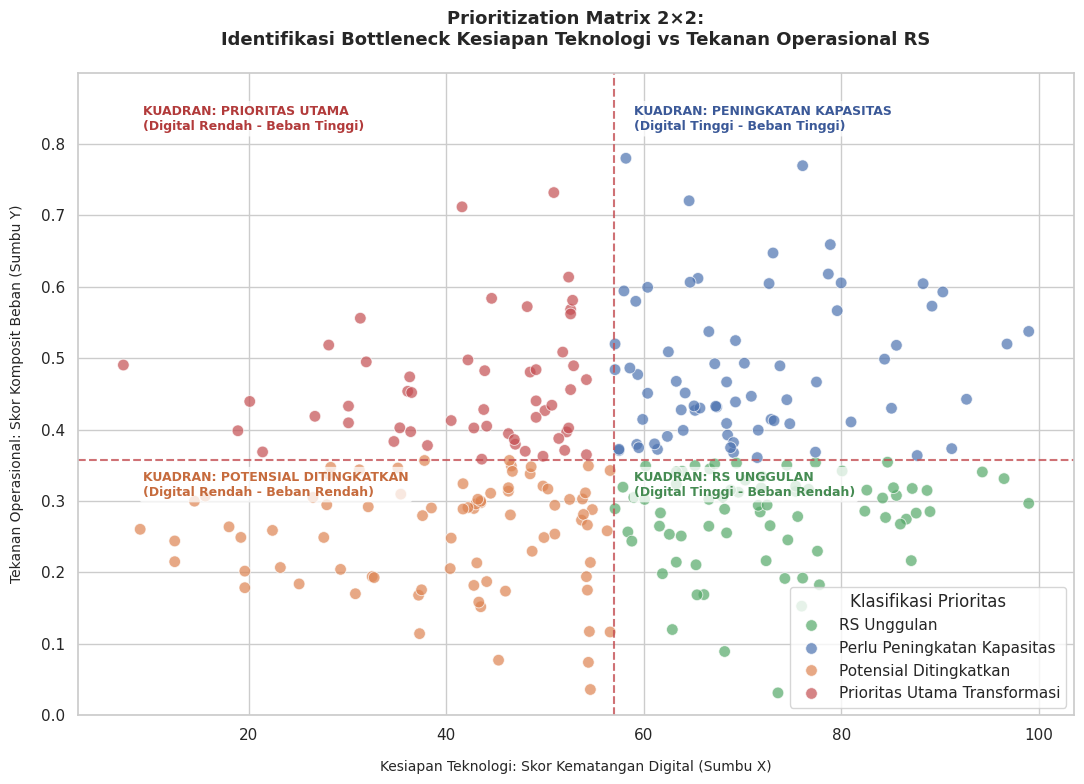

In [ ]:
plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=df_pilar_c, x='skor_kematangan_digital', y='beban_operasional', hue='kuadran_prioritas',
    palette={'RS Unggulan': '#55a868', 'Perlu Peningkatan Kapasitas': '#4c72b0',
             'Potensial Ditingkatkan': '#dd8452', 'Prioritas Utama Transformasi': '#c44e52'},
    alpha=0.7, s=70)

plt.axvline(x=x_mean_threshold, color='#c44e52', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=y_mean_threshold, color='#c44e52', linestyle='--', linewidth=1.5, alpha=0.8)

plt.ylim(0.0, df_pilar_c['beban_operasional'].max() + 0.12)
box_style = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.75)

plt.text(x_mean_threshold + 2, y_mean_threshold - 0.05, 'KUADRAN: RS UNGGULAN\n(Digital Tinggi - Beban Rendah)', fontsize=9, color='#458b52', weight='bold', bbox=box_style)
plt.text(x_mean_threshold + 2, df_pilar_c['beban_operasional'].max() + 0.04, 'KUADRAN: PENINGKATAN KAPASITAS\n(Digital Tinggi - Beban Tinggi)', fontsize=9, color='#3b5998', weight='bold', bbox=box_style)
plt.text(df_pilar_c['skor_kematangan_digital'].min() + 2, y_mean_threshold - 0.05, 'KUADRAN: POTENSIAL DITINGKATKAN\n(Digital Rendah - Beban Rendah)', fontsize=9, color='#c66b3d', weight='bold', bbox=box_style)
plt.text(df_pilar_c['skor_kematangan_digital'].min() + 2, df_pilar_c['beban_operasional'].max() + 0.04, 'KUADRAN: PRIORITAS UTAMA\n(Digital Rendah - Beban Tinggi)', fontsize=9, color='#b23b3b', weight='bold', bbox=box_style)

plt.title('Prioritization Matrix 2×2:\nIdentifikasi Bottleneck Kesiapan Teknologi vs Tekanan Operasional RS', fontsize=13, weight='bold', pad=20)
plt.xlabel('Kesiapan Teknologi: Skor Kematangan Digital (Sumbu X)', fontsize=10, labelpad=12)
plt.ylabel('Tekanan Operasional: Skor Komposit Beban (Sumbu Y)', fontsize=10, labelpad=12)
plt.legend(title='Klasifikasi Prioritas', loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
print(df_pilar_c['kuadran_prioritas'].value_counts())

kuadran_prioritas
Potensial Ditingkatkan          80
RS Unggulan                     71
Perlu Peningkatan Kapasitas     70
Prioritas Utama Transformasi    52
Name: count, dtype: int64


###

Analisis Batas Kritis Kualifikas

In [ ]:
threshold_digital = df_pilar_c['skor_kematangan_digital'].quantile(0.40)
threshold_respons = df_pilar_c['rata_rata_waktu_respons_rujukan_menit'].quantile(0.60)

In [ ]:
df_pilar_c['status_efisiensi'] = np.where(
    (df_pilar_c['skor_kematangan_digital'] < threshold_digital) &
    (df_pilar_c['rata_rata_waktu_respons_rujukan_menit'] > threshold_respons),
    'Inefisiensi Ganda (Bottleneck)', 'Normal/Efisien')

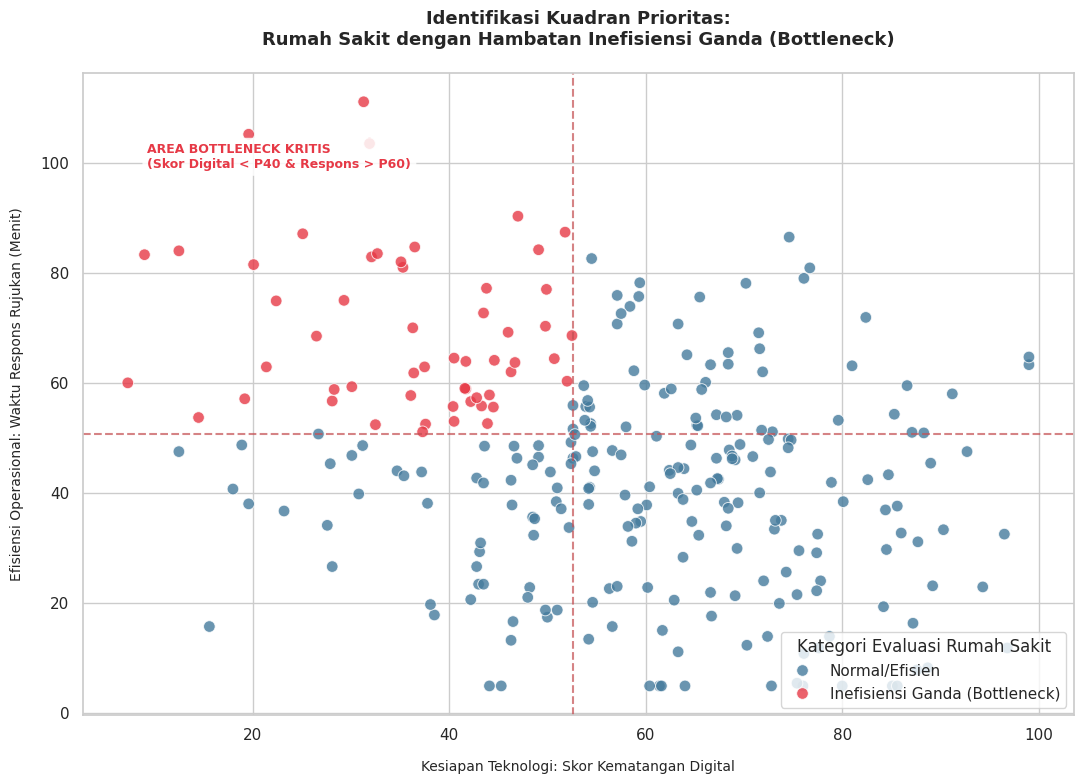

In [ ]:
plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=df_pilar_c, x='skor_kematangan_digital', y='rata_rata_waktu_respons_rujukan_menit', hue='status_efisiensi',
    palette={'Inefisiensi Ganda (Bottleneck)': '#E63946', 'Normal/Efisien': '#457B9D'}, alpha=0.8, s=70)

plt.axvline(x=threshold_digital, color='#c44e52', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(y=threshold_respons, color='#c44e52', linestyle='--', alpha=0.7, linewidth=1.5)

box_style_crit = dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='none', alpha=0.85)
plt.text(df_pilar_c['skor_kematangan_digital'].min() + 2, df_pilar_c['rata_rata_waktu_respons_rujukan_menit'].max() - 12,
         'AREA BOTTLENECK KRITIS\n(Skor Digital < P40 & Respons > P60)', color='#E63946', weight='bold', fontsize=9, bbox=box_style_crit)

plt.title('Identifikasi Kuadran Prioritas:\nRumah Sakit dengan Hambatan Inefisiensi Ganda (Bottleneck)', fontsize=13, weight='bold', pad=20)
plt.xlabel('Kesiapan Teknologi: Skor Kematangan Digital', fontsize=10, labelpad=12)
plt.ylabel('Efisiensi Operasional: Waktu Respons Rujukan (Menit)', fontsize=10, labelpad=12)
plt.legend(title='Kategori Evaluasi Rumah Sakit', loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
df_bottleneck = df_pilar_c[df_pilar_c['status_efisiensi'] == 'Inefisiensi Ganda (Bottleneck)']

print(f"Batas Maksimal Skor Digital Rendah (P40) : {threshold_digital:.2f}")
print(f"Batas Minimal Waktu Respons Lama (P60)   : {threshold_respons:.2f} menit")
print(f"Jumlah Rumah Sakit di Area Bottleneck    : {len(df_bottleneck)} RS\n")

print("==================================================")
print("     PROFIL KELOMPOK INEFISIENSI GANDA PER KELAS  ")
print("==================================================")
print(df_bottleneck['kelas_rumah_sakit'].value_counts().to_markdown())
print("\nPersentase per Kelas (%):")
print((df_bottleneck['kelas_rumah_sakit'].value_counts(normalize=True) * 100).to_markdown())

print("\n==================================================")
print("    PERBANDINGAN ALOKASI SUMBER DAYA IT OPERASIONAL")
print("==================================================")
perbandingan_sumber_daya = df_pilar_c.groupby('status_efisiensi')[
    ['anggaran_it_tahunan_juta_rupiah', 'jumlah_staf_it', 'jumlah_perangkat_iot']
].mean()
print(perbandingan_sumber_daya.to_markdown())

Batas Maksimal Skor Digital Rendah (P40) : 52.58
Batas Minimal Waktu Respons Lama (P60)   : 50.84 menit
Jumlah Rumah Sakit di Area Bottleneck    : 55 RS

     PROFIL KELOMPOK INEFISIENSI GANDA PER KELAS  
| kelas_rumah_sakit   |   count |
|:--------------------|--------:|
| C                   |      23 |
| D                   |      17 |
| B                   |      13 |
| A                   |       2 |

Persentase per Kelas (%):
| kelas_rumah_sakit   |   proportion |
|:--------------------|-------------:|
| C                   |     41.8182  |
| D                   |     30.9091  |
| B                   |     23.6364  |
| A                   |      3.63636 |

    PERBANDINGAN ALOKASI SUMBER DAYA IT OPERASIONAL
| status_efisiensi               |   anggaran_it_tahunan_juta_rupiah |   jumlah_staf_it |   jumlah_perangkat_iot |
|:-------------------------------|----------------------------------:|-----------------:|-----------------------:|
| Inefisiensi Ganda (Bottleneck) |             

###

Model yang digunakan: **K-Means Clustering** (2)


Alasannya: Algoritma unsupervised learning ini dipilih untuk memvalidasi secara objektif serta mendeteksi pola laten (tersembunyi) yang tidak mampu ditangkap oleh pembagian kaku pada analisis kuadran 2×2.

### Pemilihan Fitur

In [ ]:
fitur_cluster = ['skor_kematangan_digital', 'tingkat_keterisian_tempat_tidur_persen', 'rata_rata_waktu_respons_rujukan_menit', 'kunjungan_pasien_per_bulan']
X_multidimensi = df_pilar_c[fitur_cluster].copy()

### Standardisasi Fitur (Scaling menggunakan StandardScaler)

Menyetarakan Bobot Vektor.

In [ ]:
scaler_km = StandardScaler()
X_scaled_km = scaler_km.fit_transform(X_multidimensi)

### Jumlah Klaster Optimal (Elbow Method)

Menjalankan simulasi perulangan dari 1 hingga 10 klaster untuk menghitung nilai WCSS (inersia) dan memplotnya ke grafik untuk melihat titik siku (elbow) yang paling melandai.

In [ ]:
wcss_inersia = []
range_k = range(1, 11)
for k in range_k:
    km_test = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km_test.fit(X_scaled_km)
    wcss_inersia.append(km_test.inertia_)

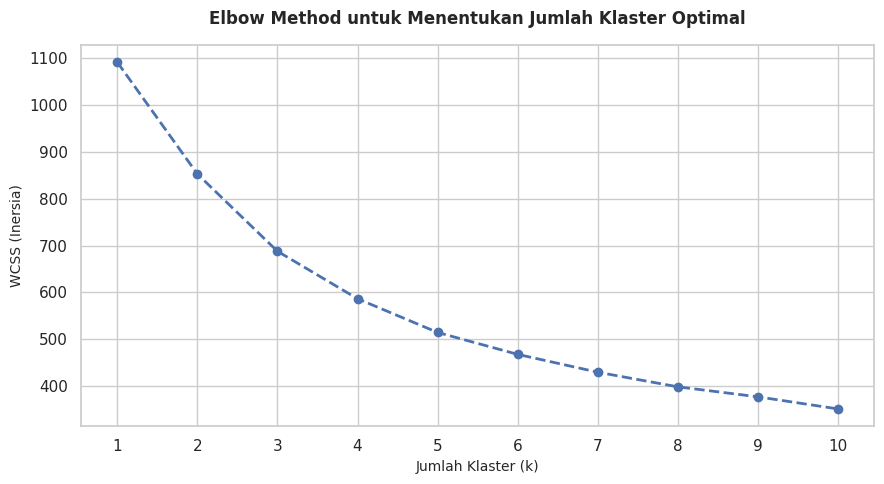

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(range_k, wcss_inersia, marker='o', linestyle='--', color='#4c72b0', linewidth=2)
plt.title('Elbow Method untuk Menentukan Jumlah Klaster Optimal', fontsize=12, weight='bold', pad=15)
plt.xlabel('Jumlah Klaster (k)', fontsize=10)
plt.ylabel('WCSS (Inersia)', fontsize=10)
plt.xticks(range_k)
plt.tight_layout()
plt.show()

### Melatih Model K-Means

In [ ]:
k_final = 4
kmeans_model = KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10)
df_pilar_c['Klaster_KMeans'] = kmeans_model.fit_predict(X_scaled_km)

### Visualisasi

In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
sns.set_theme(style="whitegrid", rc={"font.family": "sans-serif"})

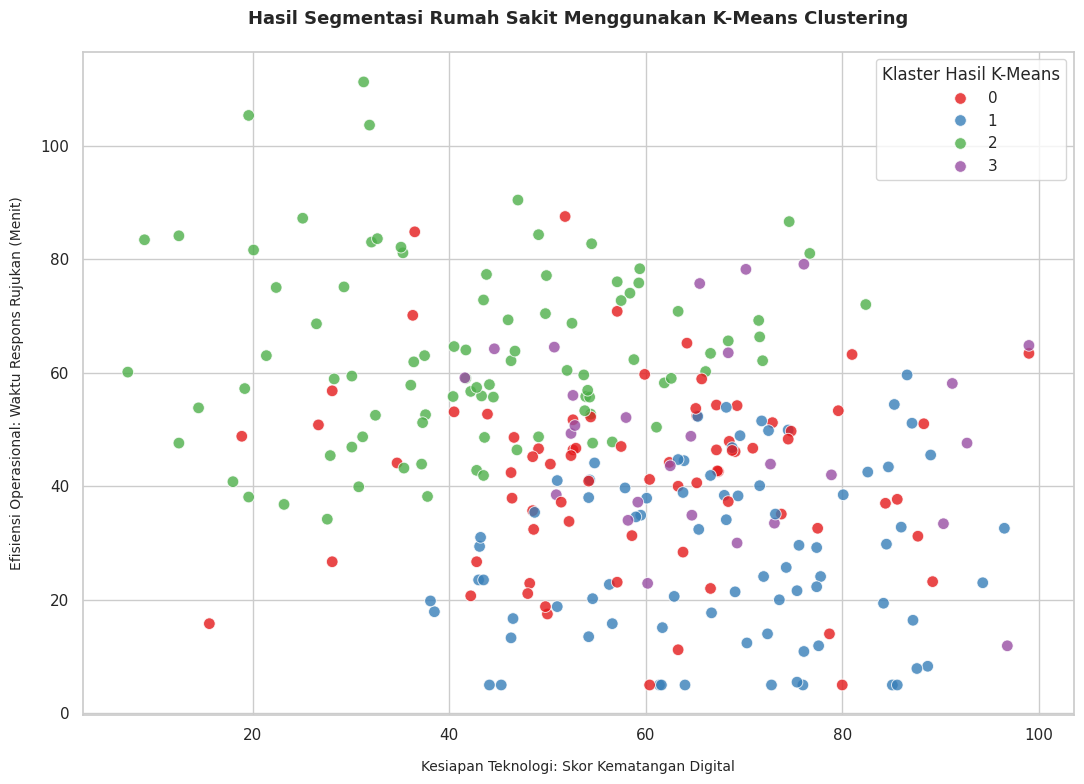

In [ ]:
plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=df_pilar_c, x='skor_kematangan_digital', y='rata_rata_waktu_respons_rujukan_menit',
    hue='Klaster_KMeans', palette='Set1', alpha=0.8, s=70)

plt.title('Hasil Segmentasi Rumah Sakit Menggunakan K-Means Clustering', fontsize=13, weight='bold', pad=20)
plt.xlabel('Kesiapan Teknologi: Skor Kematangan Digital', fontsize=10, labelpad=12)
plt.ylabel('Efisiensi Operasional: Waktu Respons Rujukan (Menit)', fontsize=10, labelpad=12)
plt.legend(title='Klaster Hasil K-Means', loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
print("Profil dan Karakteristik Rata-Rata setiap Kluster")
profil_klaster_final = df_pilar_c.groupby('Klaster_KMeans')[fitur_cluster].mean()
print(profil_klaster_final.to_markdown())

Profil dan Karakteristik Rata-Rata setiap Kluster
|   Klaster_KMeans |   skor_kematangan_digital |   tingkat_keterisian_tempat_tidur_persen |   rata_rata_waktu_respons_rujukan_menit |   kunjungan_pasien_per_bulan |
|-----------------:|--------------------------:|-----------------------------------------:|----------------------------------------:|-----------------------------:|
|                0 |                   58.88   |                                  82.3613 |                                 42.1467 |                      1380.75 |
|                1 |                   67.6813 |                                  61.7575 |                                 27.8825 |                      1432.06 |
|                2 |                   42.9143 |                                  62.1615 |                                 63.3846 |                      1507.92 |
|                3 |                   67.3037 |                                  67.0741 |                                 4

## **Insight Tambahan**

### Analisis ROI Digital & Indeks Efisiensi

In [ ]:
df_pilar_c['indeks_efisiensi'] = df_pilar_c['skor_kematangan_digital'] / df_pilar_c['anggaran_it_tahunan_juta_rupiah']

df_roi_sorting = df_pilar_c[['id_rumah_sakit', 'nama_rumah_sakit', 'kelas_rumah_sakit',
                             'skor_kematangan_digital', 'anggaran_it_tahunan_juta_rupiah',
                             'indeks_efisiensi']].sort_values(by='indeks_efisiensi', ascending=False)

print("==================================================")
print("5 Rumah Sakit Paling Efisien (ROI Digital Tinggi)")
print("==================================================")
print(df_roi_sorting.head(5).to_markdown(index=False))

print("\n==================================================")
print("5 Rumah Sakit Paling Boros (ROI Digital Rendah)")
print("==================================================")
print(df_roi_sorting.tail(5).to_markdown(index=False))

5 Rumah Sakit Paling Efisien (ROI Digital Tinggi)
| id_rumah_sakit   | nama_rumah_sakit     | kelas_rumah_sakit   |   skor_kematangan_digital |   anggaran_it_tahunan_juta_rupiah |   indeks_efisiensi |
|:-----------------|:---------------------|:--------------------|--------------------------:|----------------------------------:|-------------------:|
| RS0235           | Rs Permata Bunda 6   | C                   |                      19.6 |                               5   |            3.92    |
| RS0202           | Rs Bhakti Husada 7   | D                   |                      19.6 |                               5   |            3.92    |
| RS0168           | Rs Sejahtera 8       | C                   |                      22.4 |                               6.8 |            3.29412 |
| RS0162           | Rsud Bhakti Husada 2 | D                   |                      32.5 |                              10.9 |            2.98165 |
| RS0262           | Rs Husada Mulia 3    | 

In [ ]:
df_provinsi = df_pilar_c.copy()

df_agregasi_prov = df_provinsi.groupby('provinsi').agg(
    rata_rata_skor_digital=('skor_kematangan_digital', 'mean'),
    rata_rata_waktu_respons_menit=('rata_rata_waktu_respons_rujukan_menit', 'mean'),
    jumlah_rumah_sakit=('id_rumah_sakit', 'count')).reset_index()

df_agregasi_prov['rata_rata_indeks_efisiensi'] = df_provinsi.groupby('provinsi')['indeks_efisiensi'].mean().values
df_agregasi_prov = df_agregasi_prov.sort_values(by='rata_rata_skor_digital', ascending=False)

print("=========================================================================")
print("Profil Digitalisasi dan Efisiensi Operasional RS per Provinsi")
print("=========================================================================")
print(df_agregasi_prov.to_markdown(index=False, floatfmt=".2f"))

Profil Digitalisasi dan Efisiensi Operasional RS per Provinsi
| provinsi            |   rata_rata_skor_digital |   rata_rata_waktu_respons_menit |   jumlah_rumah_sakit |   rata_rata_indeks_efisiensi |
|:--------------------|-------------------------:|--------------------------------:|---------------------:|-----------------------------:|
| Bali                |                    85.57 |                           29.73 |                    7 |                         0.49 |
| Di Yogyakarta       |                    79.33 |                           42.83 |                    6 |                         0.48 |
| Banten              |                    77.91 |                           37.68 |                    9 |                         0.48 |
| Jawa Tengah         |                    76.73 |                           34.91 |                   10 |                         0.47 |
| Jawa Timur          |                    75.95 |                           35.05 |                    

In [ ]:
df_only_bottleneck = df_pilar_c[df_pilar_c['status_efisiensi'] == 'Inefisiensi Ganda (Bottleneck)'].copy()
df_pareto = df_only_bottleneck.groupby('provinsi').size().reset_index(name='jumlah_rs_bottleneck')
df_pareto = df_row_sorting = df_pareto.sort_values(by='jumlah_rs_bottleneck', ascending=False).reset_index(drop=True)

total_bottleneck = df_pareto['jumlah_rs_bottleneck'].sum()
df_pareto['persentase'] = (df_pareto['jumlah_rs_bottleneck'] / total_bottleneck) * 100
df_pareto['persentase_kumulatif'] = df_pareto['persentase'].cumsum()

print("==================================================")
print("Tabel Distribusi Kumulatif Pareto (80/20)")
print("==================================================")
print(df_pareto.to_markdown(index=False, floatfmt=".2f"))

Tabel Distribusi Kumulatif Pareto (80/20)
| provinsi            |   jumlah_rs_bottleneck |   persentase |   persentase_kumulatif |
|:--------------------|-----------------------:|-------------:|-----------------------:|
| Sulawesi Barat      |                      6 |        10.91 |                  10.91 |
| Papua               |                      5 |         9.09 |                  20.00 |
| Papua Tengah        |                      5 |         9.09 |                  29.09 |
| Kalimantan Utara    |                      5 |         9.09 |                  38.18 |
| Sulawesi Tenggara   |                      5 |         9.09 |                  47.27 |
| Nusa Tenggara Timur |                      4 |         7.27 |                  54.55 |
| Maluku Utara        |                      4 |         7.27 |                  61.82 |
| Papua Barat         |                      3 |         5.45 |                  67.27 |
| Nusa Tenggara Barat |                      3 |         5.45 |     

/tmp/ipykernel_731/2395205954.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9)


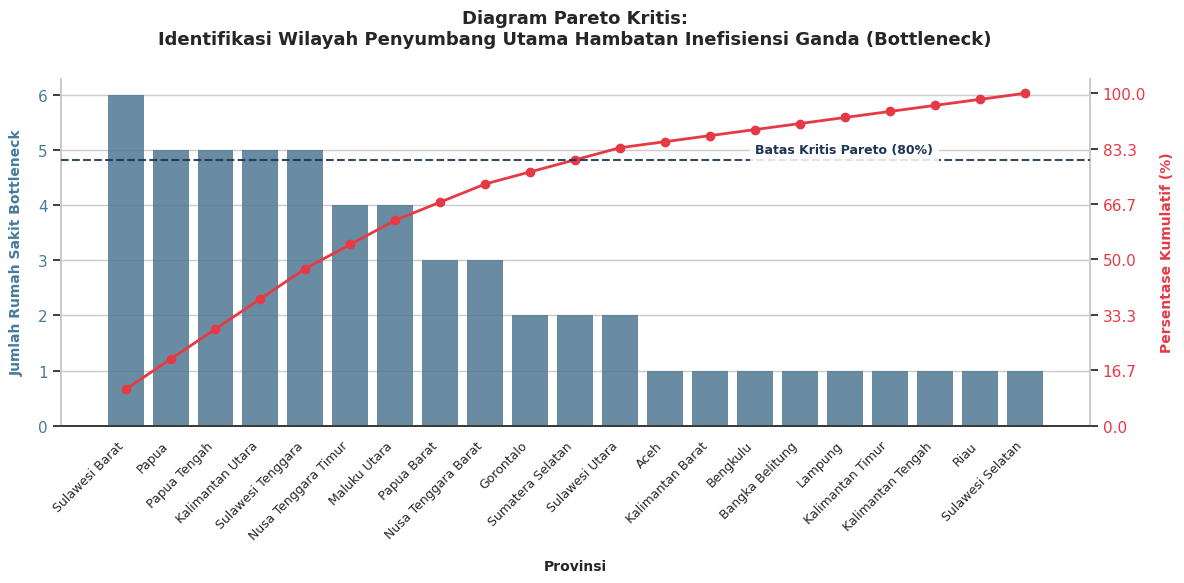

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="white", rc={"font.family": "sans-serif"})
sns.barplot(
    data=df_pareto,
    x='provinsi',
    y='jumlah_rs_bottleneck',
    ax=ax1,
    color='#457B9D',
    edgecolor='none',
    alpha=0.85)

ax1.set_ylabel('Jumlah Rumah Sakit Bottleneck', color='#457B9D', fontsize=10, labelpad=10, weight='bold')
ax1.tick_params(axis='y', labelcolor='#457B9D')
ax1.set_yticks(range(0, 7))

ax1.set_xlabel('Provinsi', fontsize=10, labelpad=12, weight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(
    df_pareto['provinsi'],
    df_pareto['persentase_kumulatif'],
    color='#E63946',
    marker='o',
    linewidth=2,
    markersize=6,
    label='Persentase Kumulatif')

ax2.set_ylabel('Persentase Kumulatif (%)', color='#E63946', fontsize=10, labelpad=10, weight='bold')
ax2.tick_params(axis='y', labelcolor='#E63946')
ax2.set_yticks(np.linspace(0, 100, 7))

for y in range(0, 7):
    ax1.axhline(y=y, color='#E0E0E0', linestyle='-', linewidth=0.8, zorder=0)

ax2.axhline(y=80, color='#1D3557', linestyle='--', alpha=0.9, linewidth=1.5, zorder=3)

ax2.text(14, 82, 'Batas Kritis Pareto (80%)', color='#1D3557', fontsize=9, weight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.85))

ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_color('#CBCBCB')
ax1.spines['bottom'].set_color('#CBCBCB')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_color('#CBCBCB')
ax2.spines['right'].set_color('#CBCBCB')

plt.title('Diagram Pareto Kritis:\nIdentifikasi Wilayah Penyumbang Utama Hambatan Inefisiensi Ganda (Bottleneck)', fontsize=13, weight='bold', pad=25)
plt.tight_layout()
plt.show()

In [ ]:
cluster_profile = df_pilar_c.groupby('Klaster_KMeans').agg(
    skor_digital=('skor_kematangan_digital', 'mean'),
    waktu_respons=('rata_rata_waktu_respons_rujukan_menit', 'mean'),
    kunjungan_bulanan=('kunjungan_pasien_per_bulan', 'mean'),
    jumlah_rs=('id_rumah_sakit', 'count')).reset_index()

def label_cluster(row):
    if row['skor_digital'] >= cluster_profile['skor_digital'].mean() and row['waktu_respons'] <= cluster_profile['waktu_respons'].mean():
        return "Digital Advanced (Efficiency Leader)"
    elif row['kunjungan_bulanan'] > cluster_profile['kunjungan_bulanan'].mean():
        return "Critical Infrastructure (High Burden)"
    elif row['skor_digital'] < cluster_profile['skor_digital'].mean():
        return "Digital Laggard"
    else:
        return "Developing Digital"

cluster_profile['nama_cluster'] = cluster_profile.apply(label_cluster, axis=1)

print("=========================================================================")
print("             Profil Cluster           ")
print("=========================================================================")
print(cluster_profile[['Klaster_KMeans', 'nama_cluster', 'jumlah_rs', 'skor_digital', 'waktu_respons']].to_markdown(index=False, floatfmt=".2f"))

             Profil Cluster           
|   Klaster_KMeans | nama_cluster                          |   jumlah_rs |   skor_digital |   waktu_respons |
|-----------------:|:--------------------------------------|------------:|---------------:|----------------:|
|                0 | Digital Laggard                       |          75 |          58.88 |           42.15 |
|                1 | Digital Advanced (Efficiency Leader)  |          80 |          67.68 |           27.88 |
|                2 | Digital Laggard                       |          91 |          42.91 |           63.38 |
|                3 | Critical Infrastructure (High Burden) |          27 |          67.30 |           48.80 |


In [ ]:
cluster_mapping_desc = {
    "Digital Advanced (Efficiency Leader)": "RS dengan tingkat digitalisasi tinggi dan operasional sangat efisien.",
    "Critical Infrastructure (High Burden)": "RS dengan beban pasien tinggi yang membutuhkan optimasi alur rujukan.",
    "Digital Laggard": "RS dengan adopsi digital rendah, perlu stimulus infrastruktur.",
    "Developing Digital": "RS dalam fase transisi adaptasi teknologi."}

cluster_profile['deskripsi'] = cluster_profile['nama_cluster'].map(cluster_mapping_desc)

In [ ]:
dashboard_json = []
for index, row in cluster_profile.iterrows():
    dashboard_json.append({
        "cluster_id": int(row['Klaster_KMeans']),
        "nama_cluster": row['nama_cluster'],
        "jumlah_rs": int(row['jumlah_rs']),
        "deskripsi": row['deskripsi'],
        "metrik": {
            "skor_digital": round(row['skor_digital'], 2),
            "waktu_respons": round(row['waktu_respons'], 2)
        }
    })

import json
with open("cluster_dashboard_4.json", 'w') as f:
    json.dump(dashboard_json, f, indent=4)

print("✅ Sukses! Deskripsi sudah ditambahkan dan JSON tersimpan.")

✅ Sukses! Deskripsi sudah ditambahkan dan JSON tersimpan.


In [ ]:
median_anggaran = df_pilar_c['anggaran_it_tahunan_juta_rupiah'].median()
median_staf = df_pilar_c['jumlah_staf_it'].median()

def kategori_quadrant(row):
    if row['anggaran_it_tahunan_juta_rupiah'] > median_anggaran and row['jumlah_staf_it'] > median_staf:
        return 'Tinggi-Tinggi'
    elif row['anggaran_it_tahunan_juta_rupiah'] > median_anggaran and row['jumlah_staf_it'] <= median_staf:
        return 'Tinggi-Rendah'
    elif row['anggaran_it_tahunan_juta_rupiah'] <= median_anggaran and row['jumlah_staf_it'] > median_staf:
        return 'Rendah-Tinggi'
    else:
        return 'Rendah-Rendah'

df_pilar_c['kuadran_it'] = df_pilar_c.apply(kategori_quadrant, axis=1)
summary_kuadran = df_pilar_c.groupby('kuadran_it')['skor_kematangan_digital'].mean().reset_index()
skor_threshold = df_pilar_c['skor_kematangan_digital'].mean()

rs_hidden_insight = df_pilar_c[
    (df_pilar_c['kuadran_it'] == 'Tinggi-Rendah') &
    (df_pilar_c['skor_kematangan_digital'] < skor_threshold)].copy()

print("=========================================================================")
print("      Rata-Rata Skor Digital berdasarkan Kuadran IT (Anggaran/SDM)       ")
print("=========================================================================")

print(rs_hidden_insight[['id_rumah_sakit', 'nama_rumah_sakit', 'anggaran_it_tahunan_juta_rupiah',
                         'jumlah_staf_it', 'skor_kematangan_digital']].rename(columns={
    'anggaran_it_tahunan_juta_rupiah': 'Anggaran_Juta',
    'jumlah_staf_it': 'Staf_IT',
    'skor_kematangan_digital': 'Skor_Digital'
}).to_markdown(index=False))

      Rata-Rata Skor Digital berdasarkan Kuadran IT (Anggaran/SDM)       
| id_rumah_sakit   | nama_rumah_sakit     |   Anggaran_Juta |   Staf_IT |   Skor_Digital |
|:-----------------|:---------------------|----------------:|----------:|---------------:|
| RS0055           | Rsud Medika Utama 5  |           153.1 |         3 |           54.8 |
| RS0082           | Rs Permata Bunda 9   |           131.6 |         4 |           56.3 |
| RS0097           | Rs Bhakti Husada 9   |           144.4 |         2 |           52.6 |
| RS0110           | Rsud Citra Medika 4  |           161.7 |         1 |           52.5 |
| RS0138           | Rs Harapan Bangsa 6  |           161.2 |         3 |           56.6 |
| RS0144           | Rs Sentosa Medika 4  |           154.9 |         2 |           43   |
| RS0150           | Rs Harapan Bangsa 10 |           133.8 |         3 |           52.4 |
| RS0155           | Rsud Cahaya Medika 5 |           123.1 |         4 |           43.1 |
| RS0186        

In [ ]:
fitur_korelasi = ['skor_kematangan_digital', 'jumlah_perangkat_iot', 'jumlah_staf_it']
df_korelasi = df_pilar_c[fitur_korelasi].corr(method='pearson')

pengaruh_faktor = df_korelasi['skor_kematangan_digital'].drop('skor_kematangan_digital')

print("=========================================================================")
print("      Analisis Faktor Pengaruh terhadap Skor Kematangan Digital      ")
print("=========================================================================")
print(pengaruh_faktor.to_frame(name='Koefisien Korelasi').to_markdown())

faktor_terkuat = pengaruh_faktor.idxmax()
nilai_terkuat = pengaruh_faktor.max()

print(f"Kesimpulan Strategis:")
print(f"Faktor dengan pengaruh terkuat adalah: {faktor_terkuat} (Nilai: {nilai_terkuat:.2f})")
if faktor_terkuat == 'jumlah_staf_it':
    print("Saran: Fokuskan investasi pada pengembangan SDM IT (Pelatihan/Rekrutmen).")
else:
    print("Saran: Fokuskan investasi pada pengadaan infrastruktur (IoT/Hardware).")

      Analisis Faktor Pengaruh terhadap Skor Kematangan Digital      
|                      |   Koefisien Korelasi |
|:---------------------|---------------------:|
| jumlah_perangkat_iot |             0.652046 |
| jumlah_staf_it       |             0.518413 |
Kesimpulan Strategis:
Faktor dengan pengaruh terkuat adalah: jumlah_perangkat_iot (Nilai: 0.65)
Saran: Fokuskan investasi pada pengadaan infrastruktur (IoT/Hardware).


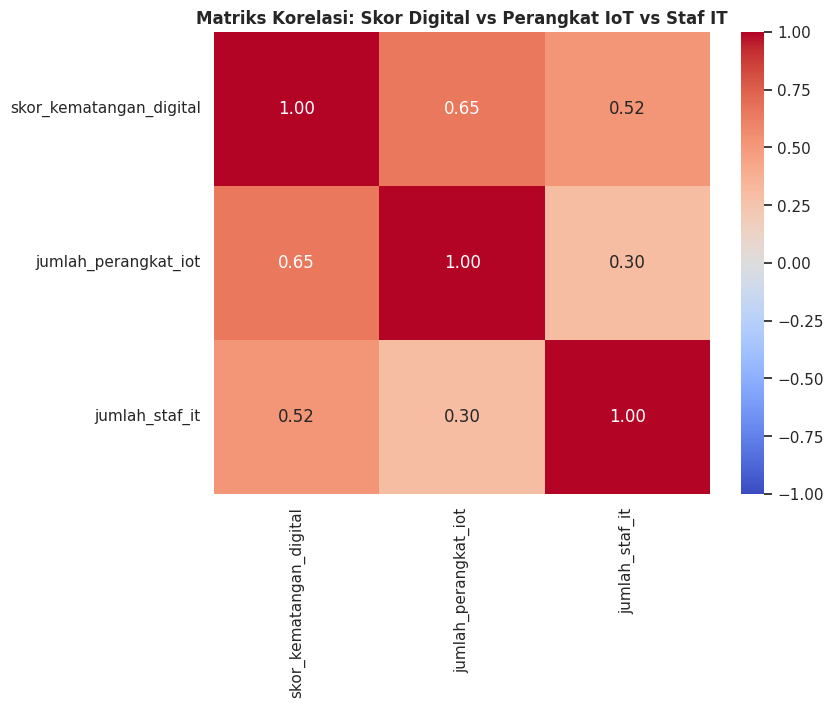

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_korelasi, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriks Korelasi: Skor Digital vs Perangkat IoT vs Staf IT', weight='bold')
plt.show()